# [LAB-03] 5. 분석결과

## #01. 준비작업

### 1. 라이브러리 참조

In [1]:
from jussam import load_data
from helpers import *
from sklearn.base import clone
import glob as gl
from sklearn.model_selection import train_test_split
# 하이퍼파라미터 튜닝
from sklearn.model_selection import GridSearchCV

📦 연세대학교 주영아 교수가 제작한 라이브러리를 사용중입니다.
📧 Email(1): j.purplerose@yonsei.ac.kr
📧 Email(2): j.purplerose@gmail.com
📝 Website: https://juyounga.kr/
🔖 Version: 0.5.19


In [21]:
# 선형 계열 모델
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet

# 비선형 계열 모델
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR

# 트리계열 모델
from sklearn.tree import DecisionTreeRegressor

# 앙상블 모델
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

### 2. 데이터 불러오기 + 타입 체크

In [2]:
# 분석용 데이터 전처리가 완료된 데이터 셋
origin = load_data("california_housing_feature_log_labelled")
df = my_qtcheck.set_type(origin, as_category=["is_age_capped", "is_income_capped", "ocean_area", "special_cluster"])

📚 캘리포니아 주택 가격 데이터셋의 파생변수 추가 버전에 대한 로그 변환 및 라벨링 처리 데이터 (출처: 자체 작업)

    field                     description
--  ------------------------  -------------------------------------------------
 0  housing_median_age        주택 중위 연령 (로그변환됨)
 1  rooms_per_person          인당 방 수 (로그변환됨)
 2  rooms_per_household       가구당 방 수 (로그변환됨)
 3  bedrooms_per_room         방당 침실 수 (로그변환됨)
 4  population_per_household  가구당 인구 (로그변환됨)
 5  income_per_person         인당 소득 (로그변환됨)
 6  is_age_capped             주택 연령 제한 여부(범주형: 제한안함=0, 제한함=1)
 7  is_income_capped          소득 제한 여부(범주형: 제한안함=0, 제한함=1)
 8  ocean_area                해양 지역 여부(범주형: COASTAL=0, INLAND=1)
 9  special_cluster           공간정보 클러스터 여부(범주형 0~4)
10  median_house_value        주택 중위 가격(종속변수, 로그변환됨)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20433 entries, 0 to 20432
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   housing_median_age   

### 3. 데이터 분할

In [ ]:
# 독립변수 분리
feature = df.drop(columns=["median_house_value"])

# 종속변수 분리
target = df["median_house_value"]

# 훈련, 검증 데이터 분할
x_train, x_test, y_train, y_test = train_test_split(
        feature, target, test_size=0.2, random_state=RANDOM_STATE)

x_train.shape, x_test.shape, y_train.shape, y_test.shape

((16346, 10), (4087, 10), (16346,), (4087,))

### 4. 저장폴더 지정

In [39]:
# 이전 학습 결과가 저장되어 있는 폴더 위치
workdir = "ml_models/20260820_034345_tuned"
workdir

'ml_models/20260820_034345_tuned'

In [40]:
# 새로운 학습 결과를 저장할 폴더 위치
savedir = workdir.replace("tuned", "importance")
savedir

'ml_models/20260820_034345_importance'

## #02. 상위 성능 모델에 대한 과적합 판정

### 1. CatBoost 

- 모델 학습시 설정한 범주형 변수 지정이 필요하다.

/Users/leekh/.pyenv/versions/3.13.9/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


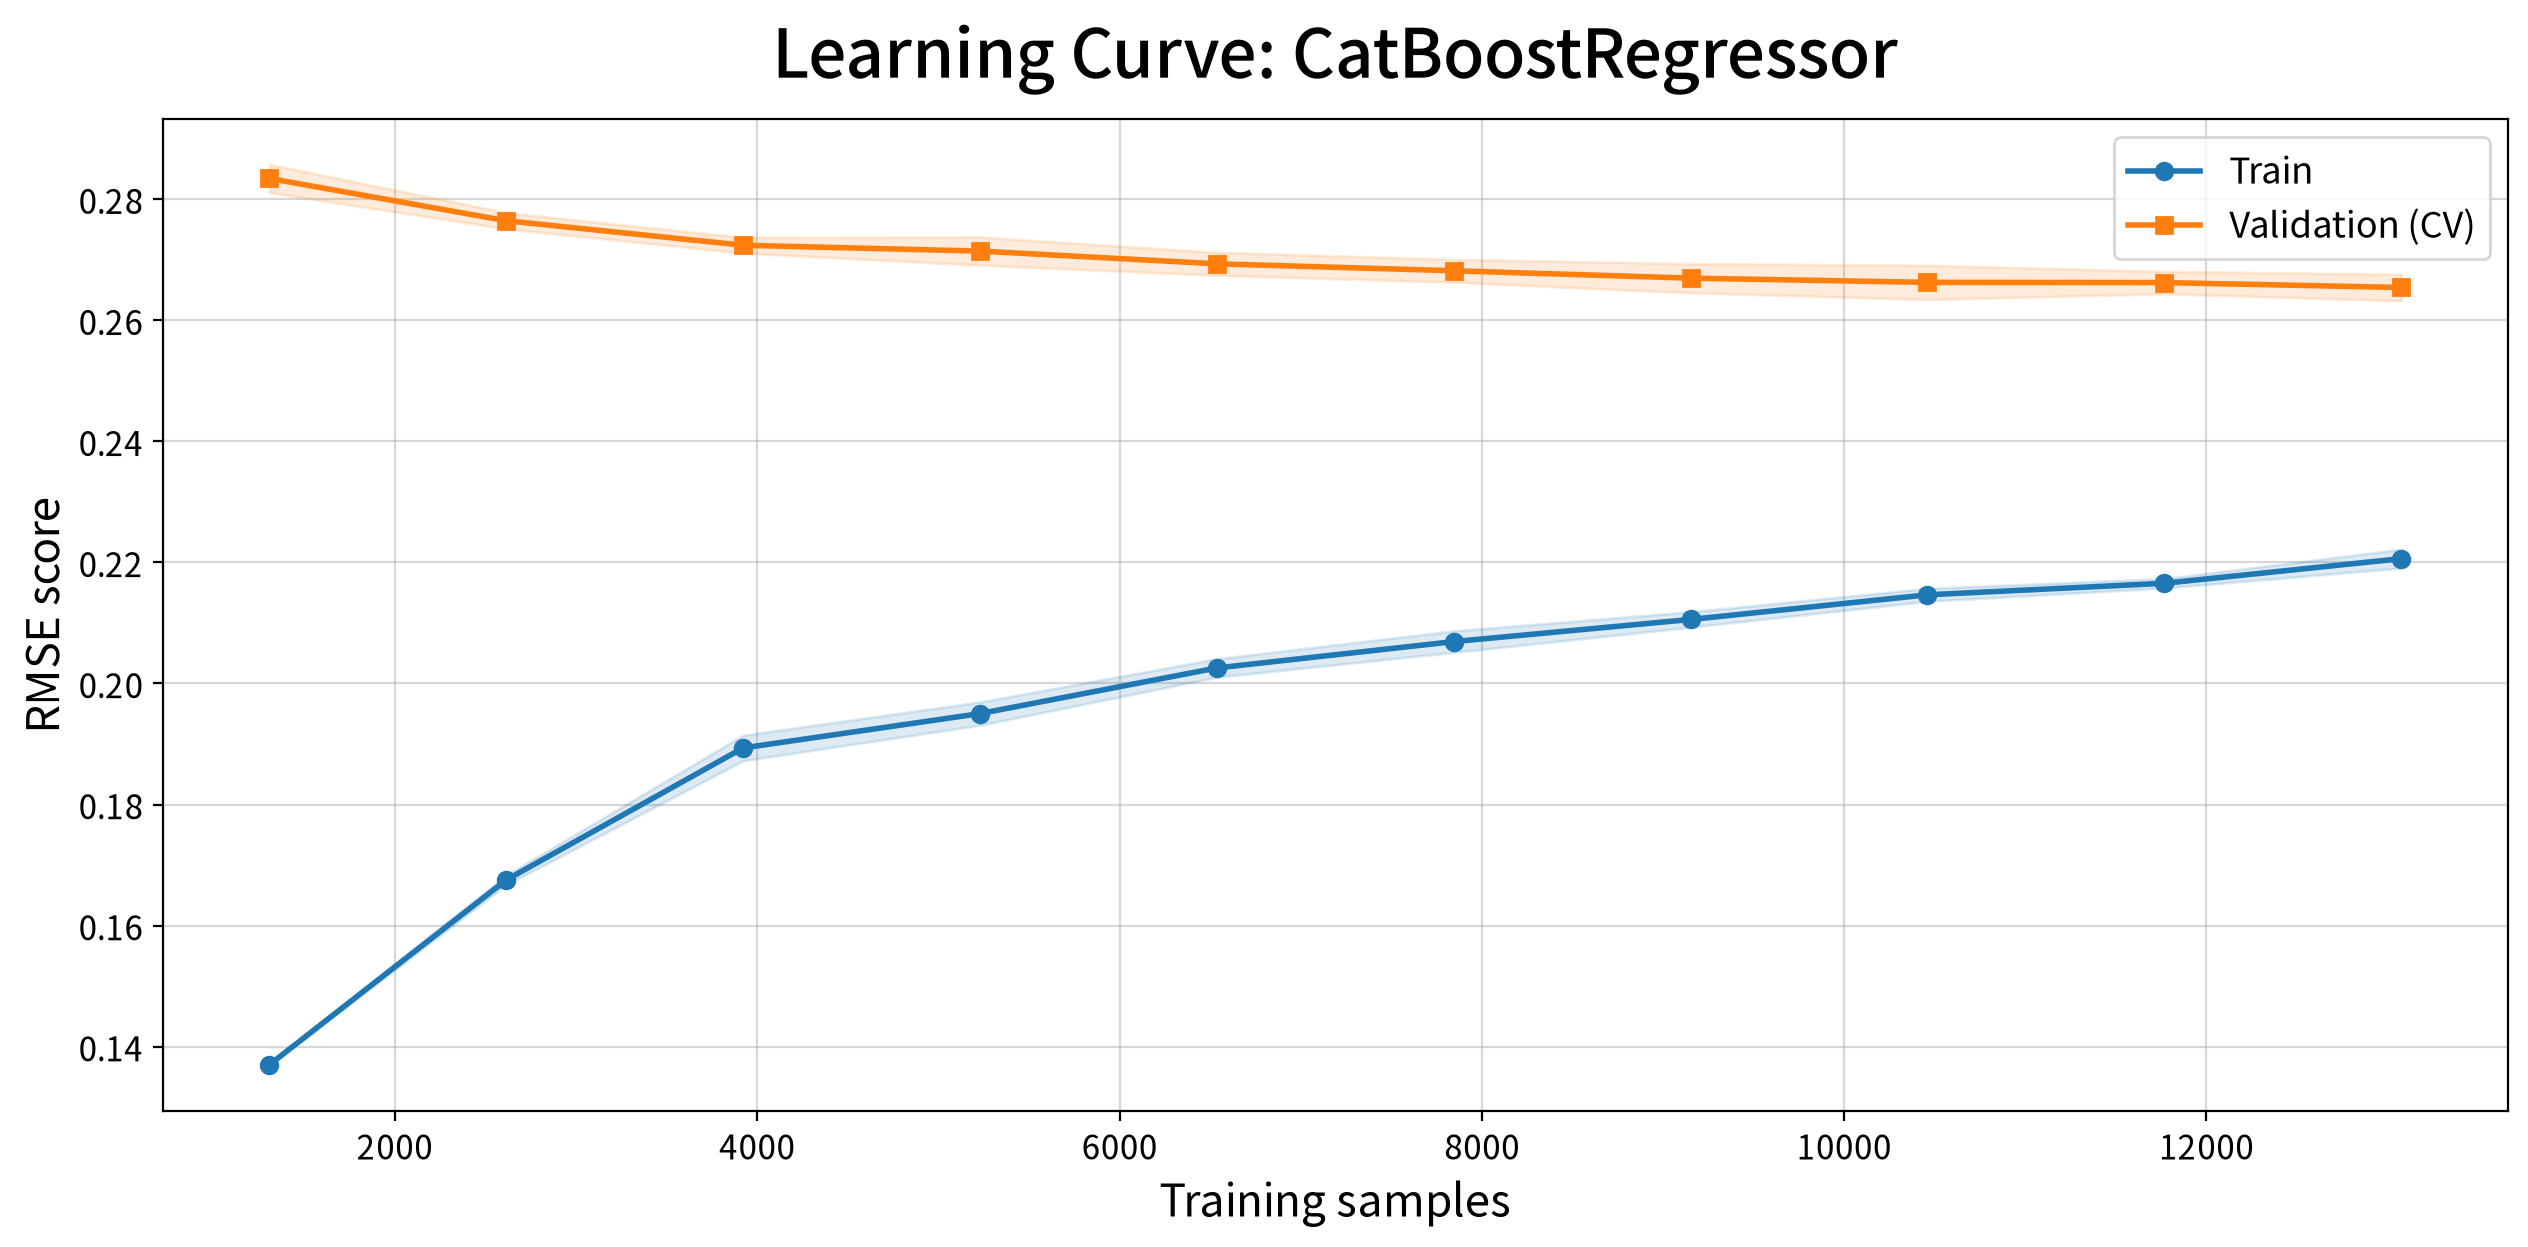


◆ Fit Diagnosis: CatBoostRegressor  (threshold=15%, 기준=Train↔CV 5-Fold)
   ▷ 탐색 객체의 best_params: {'model__depth': 8, 'model__iterations': 1000, 'model__learning_rate': 0.03}
   ※ threshold 는 학술 표준이 아닌 경험칙입니다. 임계값보다 학습곡선 추세를 함께 보세요.
   - RMSE    Train=     0.2241  CV=     0.2652 (±0.0023)  Test=     0.2651  Gap%=   15.48%  [과대적합] ⚠

   ▶ 진단: ⚠ 과대적합 (Overfit · 高분산) — 훈련↔CV 격차가 큼
     · train R2=0.8444 (과소적합 기준 < 0.3) · CV R2=0.7820

CPU times: user 280 ms, sys: 94.3 ms, total: 374 ms
Wall time: 35.9 s


,Train,CV,CV_Std,Test,Gap,Gap%,Overfit
Metric,,,,,,,
RMSE,0.224,0.265,0.002,0.265,0.041,15.480,과대적합


In [41]:
%%time
model = my_ml.load_model(f"{workdir}/catboost.pkl")
my_ml.reg_overfit(model, x_train, y_train, x_test, y_test, metrics='RMSE', fit_params={'model__cat_features': my_qtcheck.get_categorical_column_names(x_train)})

## #03. Feature Importance

### 1. Feature Importance 도출

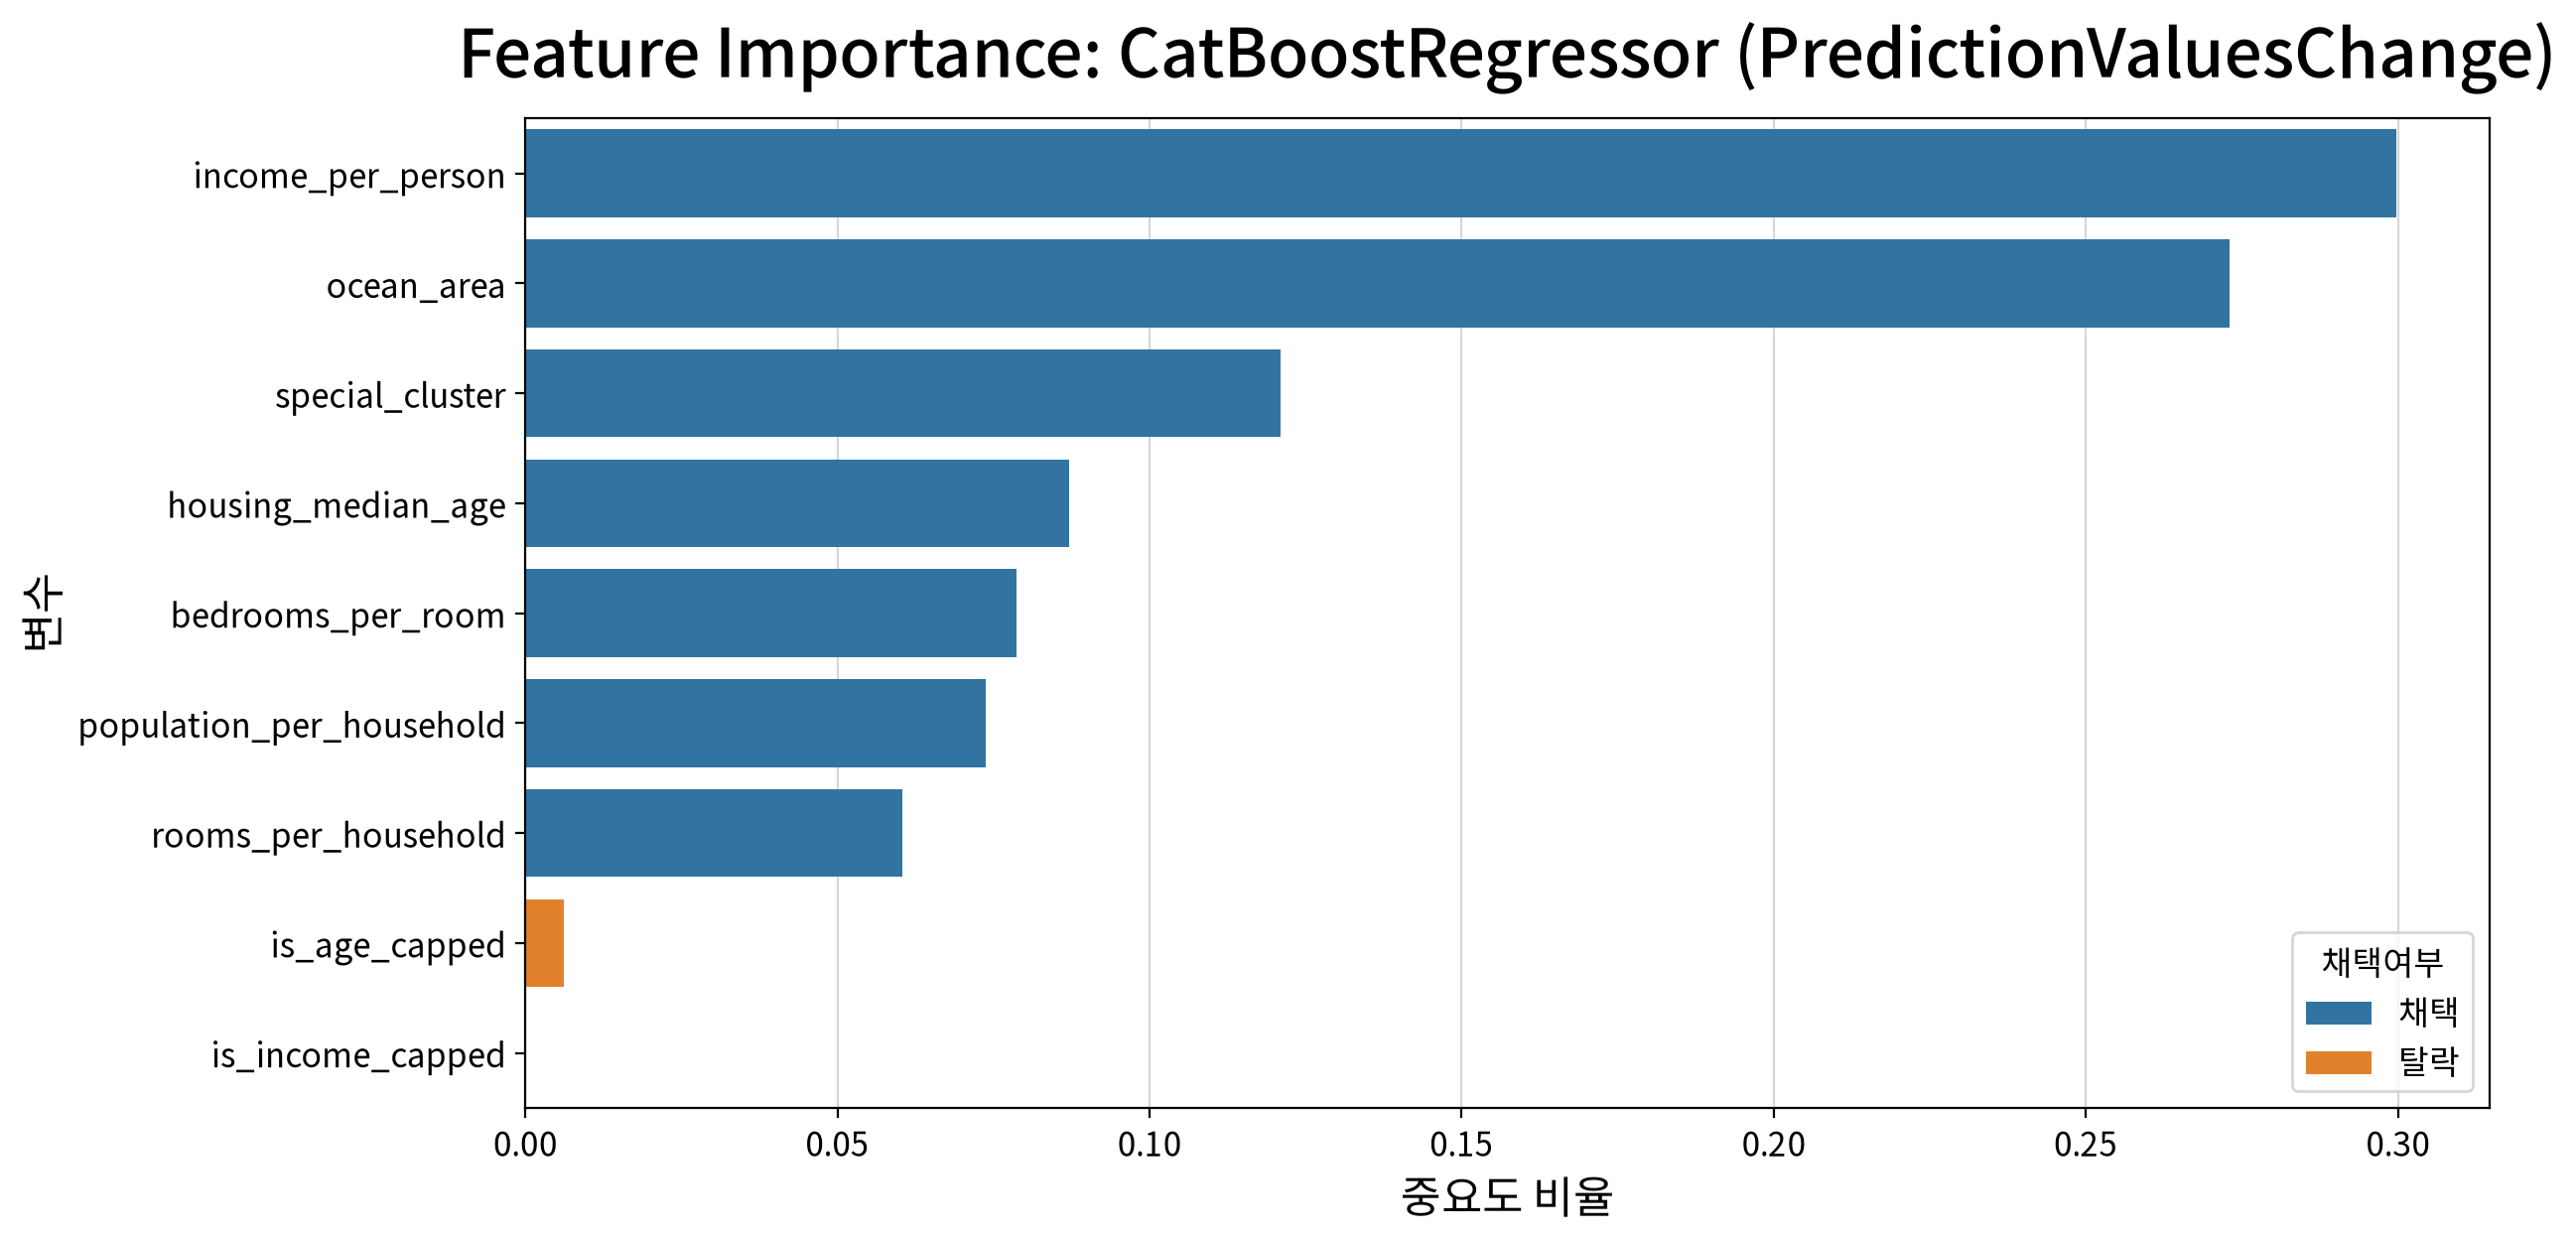


◆ Feature Importance: CatBoostRegressor  (중요도 기준=PredictionValuesChange, 채택 기준=cum_ratio=95%)
   ▷ 탐색 객체의 best_params: {'model__depth': 8, 'model__iterations': 1000, 'model__learning_rate': 0.03}
   전체 변수 9개 중 7개 채택 (누적 중요도 99.38% 설명)
   ▶ 채택된 변수: ['income_per_person', 'ocean_area', 'special_cluster', 'housing_median_age', 'bedrooms_per_room', 'population_per_household', 'rooms_per_household']



,Importance,Ratio,CumRatio,채택여부
Feature,,,,
income_per_person,29.970,0.300,0.300,채택
ocean_area,27.297,0.273,0.573,채택
special_cluster,12.099,0.121,0.694,채택
housing_median_age,8.708,0.087,0.781,채택
bedrooms_per_room,7.875,0.079,0.859,채택
population_per_household,7.384,0.074,0.933,채택
rooms_per_household,6.046,0.060,0.994,채택
is_age_capped,0.611,0.006,1.000,탈락
is_income_capped,0.010,0.000,1.000,탈락


In [43]:
model = my_ml.load_model(f"{workdir}/catboost.pkl")
fi = my_ml.feature_importance(model, cum_ratio=0.95)
fi

### 2. 채택된 변수 추출

- `feature_importance()` 의 반환 표에서 채택/탈락을 확인하고    
   **채택된 변수 목록만** 꺼내 재학습에 사용한다.

In [ ]:
# 채택된 변수 목록 (재학습에 사용)
selected = fi.attrs['selected_features']
dropped = [c for c in x_train.columns if c not in selected]

print(f"채택 {len(selected)}개: {selected}")
print(f"탈락 {len(dropped)}개: {dropped}")

채택 7개: ['income_per_person', 'ocean_area', 'special_cluster', 'housing_median_age', 'bedrooms_per_room', 'population_per_household', 'rooms_per_household']
탈락 3개: ['rooms_per_person', 'is_age_capped', 'is_income_capped']


### 3. 데이터에서 채택된 변수만 추출

In [ ]:
# 훈련 데이터에서 채택된 변수만 추출
x_tr = x_train[selected]
display(x_tr.columns)

# 검증 데이터에서 채택된 변수만 추출
x_te = x_test[selected]
display(x_te.columns)

Index(['income_per_person', 'ocean_area', 'special_cluster',
       'housing_median_age', 'bedrooms_per_room', 'population_per_household',
       'rooms_per_household'],
      dtype='object')

Index(['income_per_person', 'ocean_area', 'special_cluster',
       'housing_median_age', 'bedrooms_per_room', 'population_per_household',
       'rooms_per_household'],
      dtype='object')

### 4. 베이스모델 재학습

In [ ]:
catboost = my_ml.fit_pipeline(
            model=CatBoostRegressor(
                    random_state=RANDOM_STATE, verbose=0),
            x_train=x_tr, y_train=y_train,
            vif=True, 
            encode=False,   # CatBoost는 자체적으로 범주형 처리하므로 encode=False
            # 이름이 `단계명__인자명` 형식인 인자는 모델의 fit 으로 그대로 전달된다
            model__cat_features=my_qtcheck.get_categorical_column_names(x_tr))

display(my_ml.reg_score(catboost, x_test, y_test))

catboost

대상: 16346행 x 7열 | 모델: CatBoostRegressor
명목형: ['ocean_area', 'special_cluster']
연속형: ['income_per_person', 'housing_median_age', 'bedrooms_per_room', 'population_per_household', 'rooms_per_household']

전처리 단계
  연속형: 다중공선성 제거(VIF >= 10.0)
  명목형: (변환 없음)

모델 학습 완료: CatBoostRegressor


,R2,MAE,MSE,RMSE,RMSLE,MAPE,MPE
Model,,,,,,,
CatBoostRegressor,0.783,0.195,0.071,0.267,0.021,1.618,-0.043


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transfor

### 5. 하이퍼파라미터 튜닝

In [ ]:
# 수업용 탐색 조합
param_grid = {
    "model__iterations": [500, 1000],
    "model__depth": [4, 6, 8],
    "model__learning_rate": [0.03, 0.05, 0.1]
}

# 하이퍼파라미터 튜닝 수행
gs = GridSearchCV(estimator=catboost, param_grid=param_grid,
    cv=5, scoring="neg_root_mean_squared_error", n_jobs=-1)

gs.fit(x_tr, y_train,
       model__cat_features=my_qtcheck.get_categorical_column_names(x_tr))

gs.name_ = f"{model.name_}_tuned"   # 튜닝이 완료된 객체에게 모델이름을 부여한다.
my_ml.save_model(gs, f"{savedir}/catboost.pkl") # 튜닝이 완료된 모델을 저장한다.
display(my_ml.reg_score(gs, x_te, y_test))      # 성능 평가

,R2,MAE,MSE,RMSE,RMSLE,MAPE,MPE
Model,,,,,,,
CatBoostRegressor,0.786,0.193,0.070,0.265,0.020,1.601,-0.048


### 6. 과적합 판정

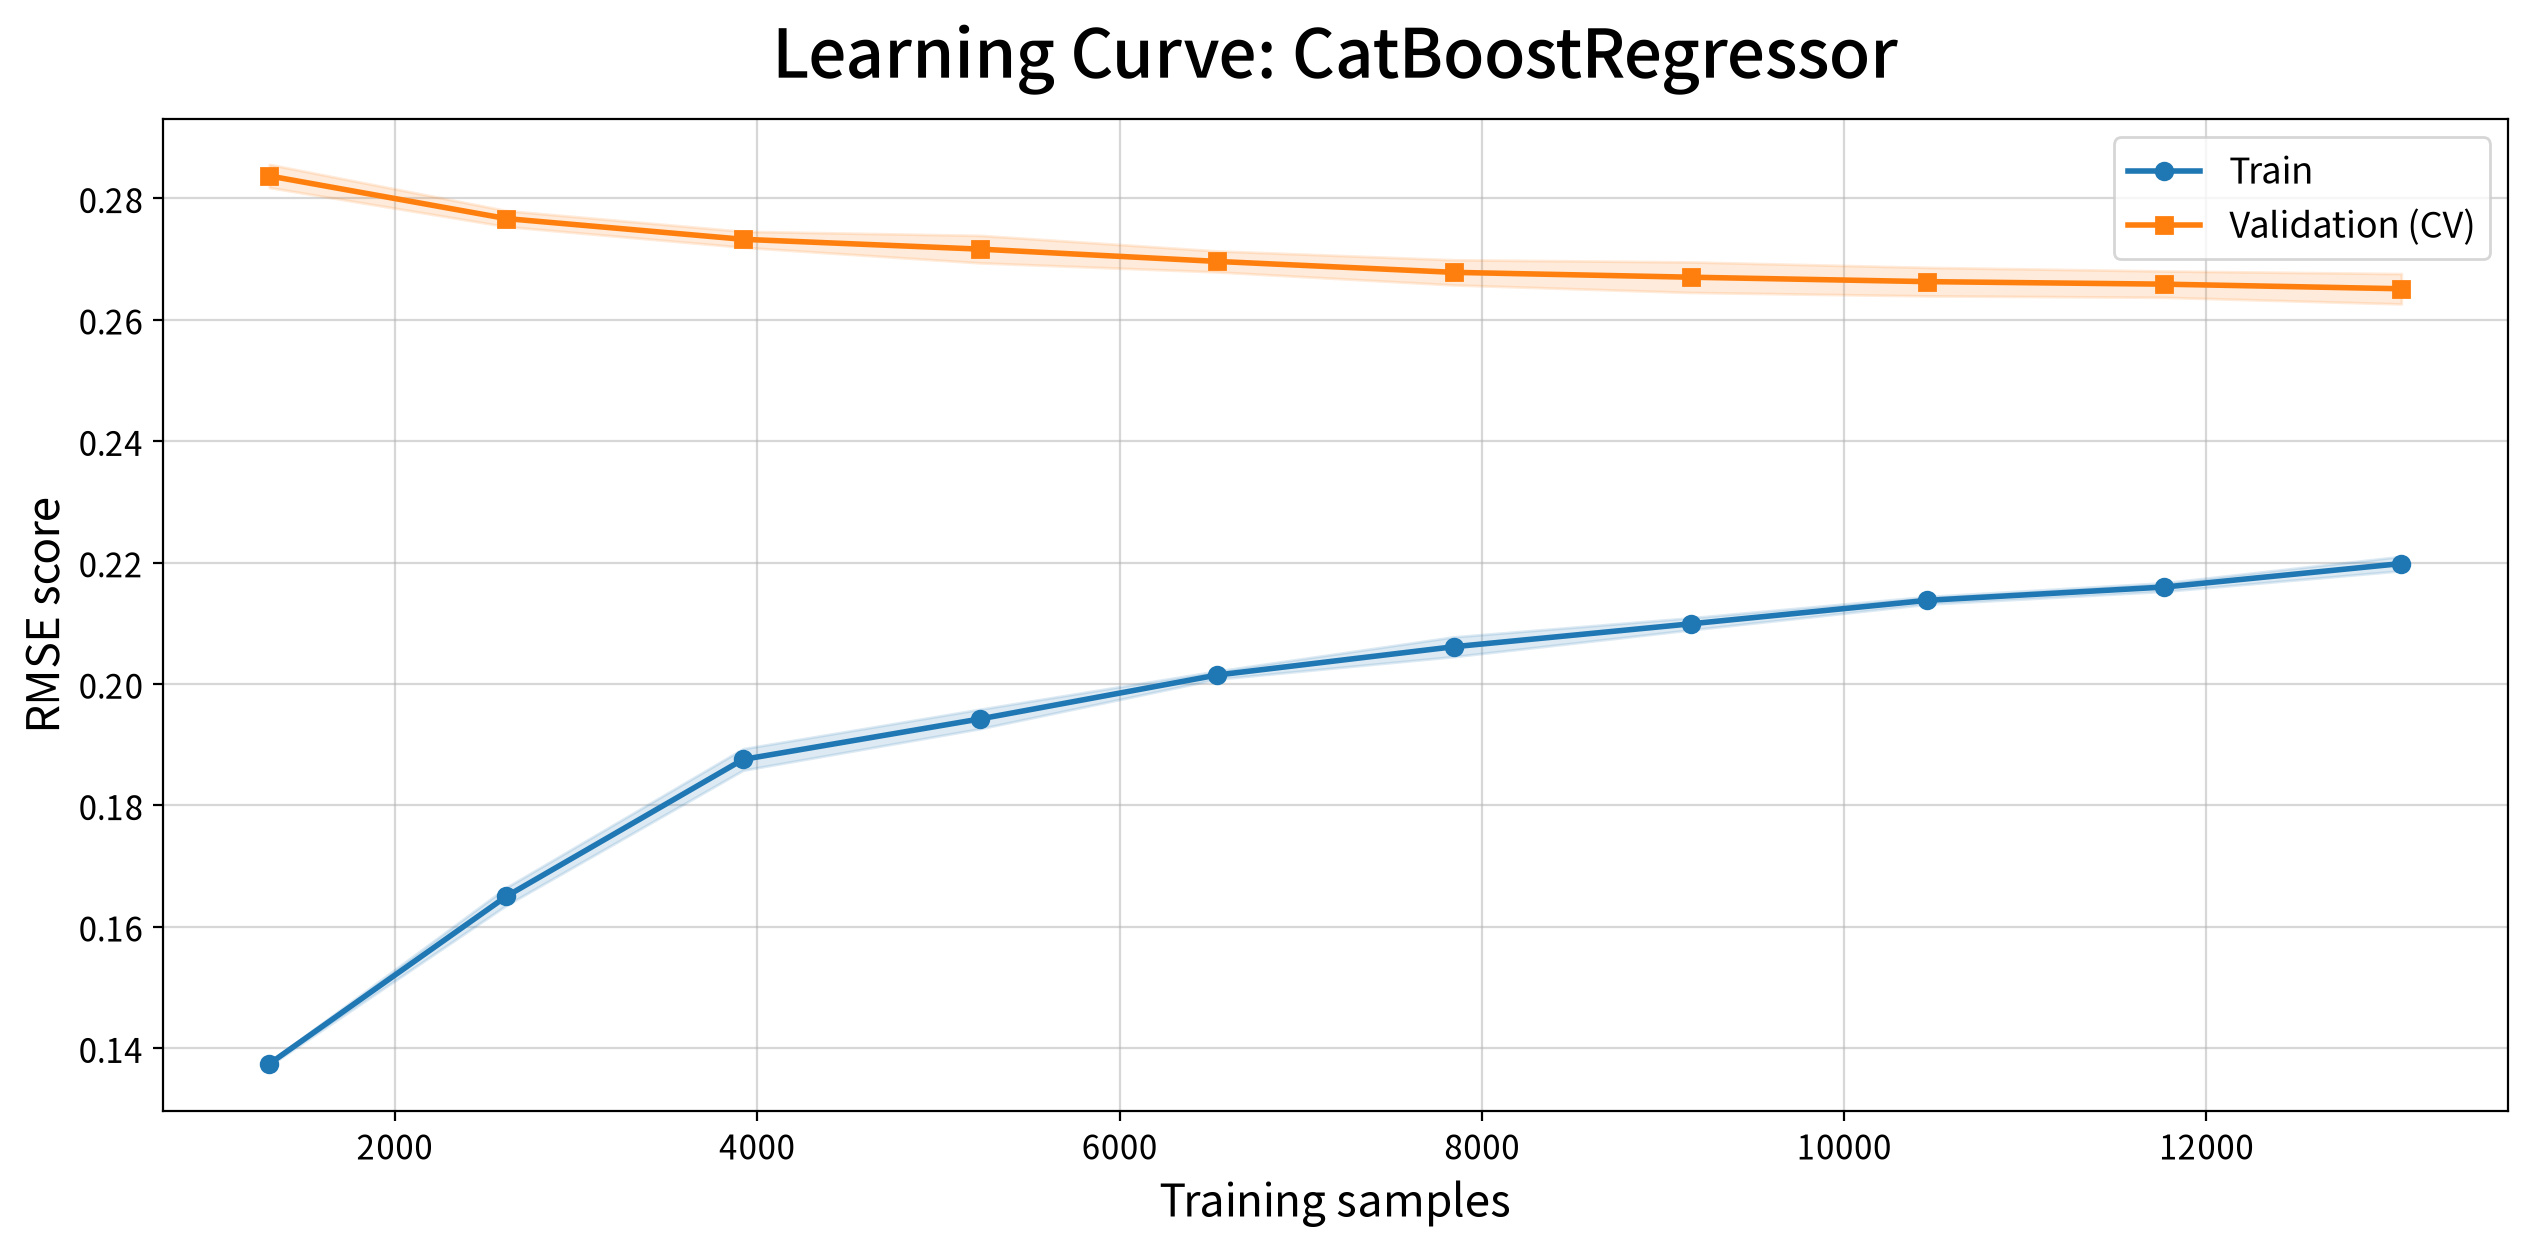


◆ Fit Diagnosis: CatBoostRegressor  (threshold=15%, 기준=Train↔CV 5-Fold)
   ▷ 탐색 객체의 best_params: {'model__depth': 8, 'model__iterations': 1000, 'model__learning_rate': 0.03}
   ※ threshold 는 학술 표준이 아닌 경험칙입니다. 임계값보다 학습곡선 추세를 함께 보세요.
   - RMSE    Train=     0.2230  CV=     0.2655 (±0.0026)  Test=     0.2650  Gap%=   15.98%  [과대적합] ⚠

   ▶ 진단: ⚠ 과대적합 (Overfit · 高분산) — 훈련↔CV 격차가 큼
     · train R2=0.8459 (과소적합 기준 < 0.3) · CV R2=0.7816

CPU times: user 333 ms, sys: 267 ms, total: 600 ms
Wall time: 47.5 s


,Train,CV,CV_Std,Test,Gap,Gap%,Overfit
Metric,,,,,,,
RMSE,0.223,0.265,0.003,0.265,0.042,15.980,과대적합


In [44]:
%%time
my_ml.reg_overfit(gs, x_tr, y_train, x_te, y_test, metrics="RMSE", 
    fit_params={'model__cat_features': my_qtcheck.get_categorical_column_names(x_tr)})

## #04 SHAP 분석

### 1. SHAP Explainer 객체 생성

- 모듈 내부에서 모델 유형에 맞는 Explainer가 생성된다.
- 두 종류의 Summary Plot이 시각화 된다 (Bar Plot과 Beeswarm)

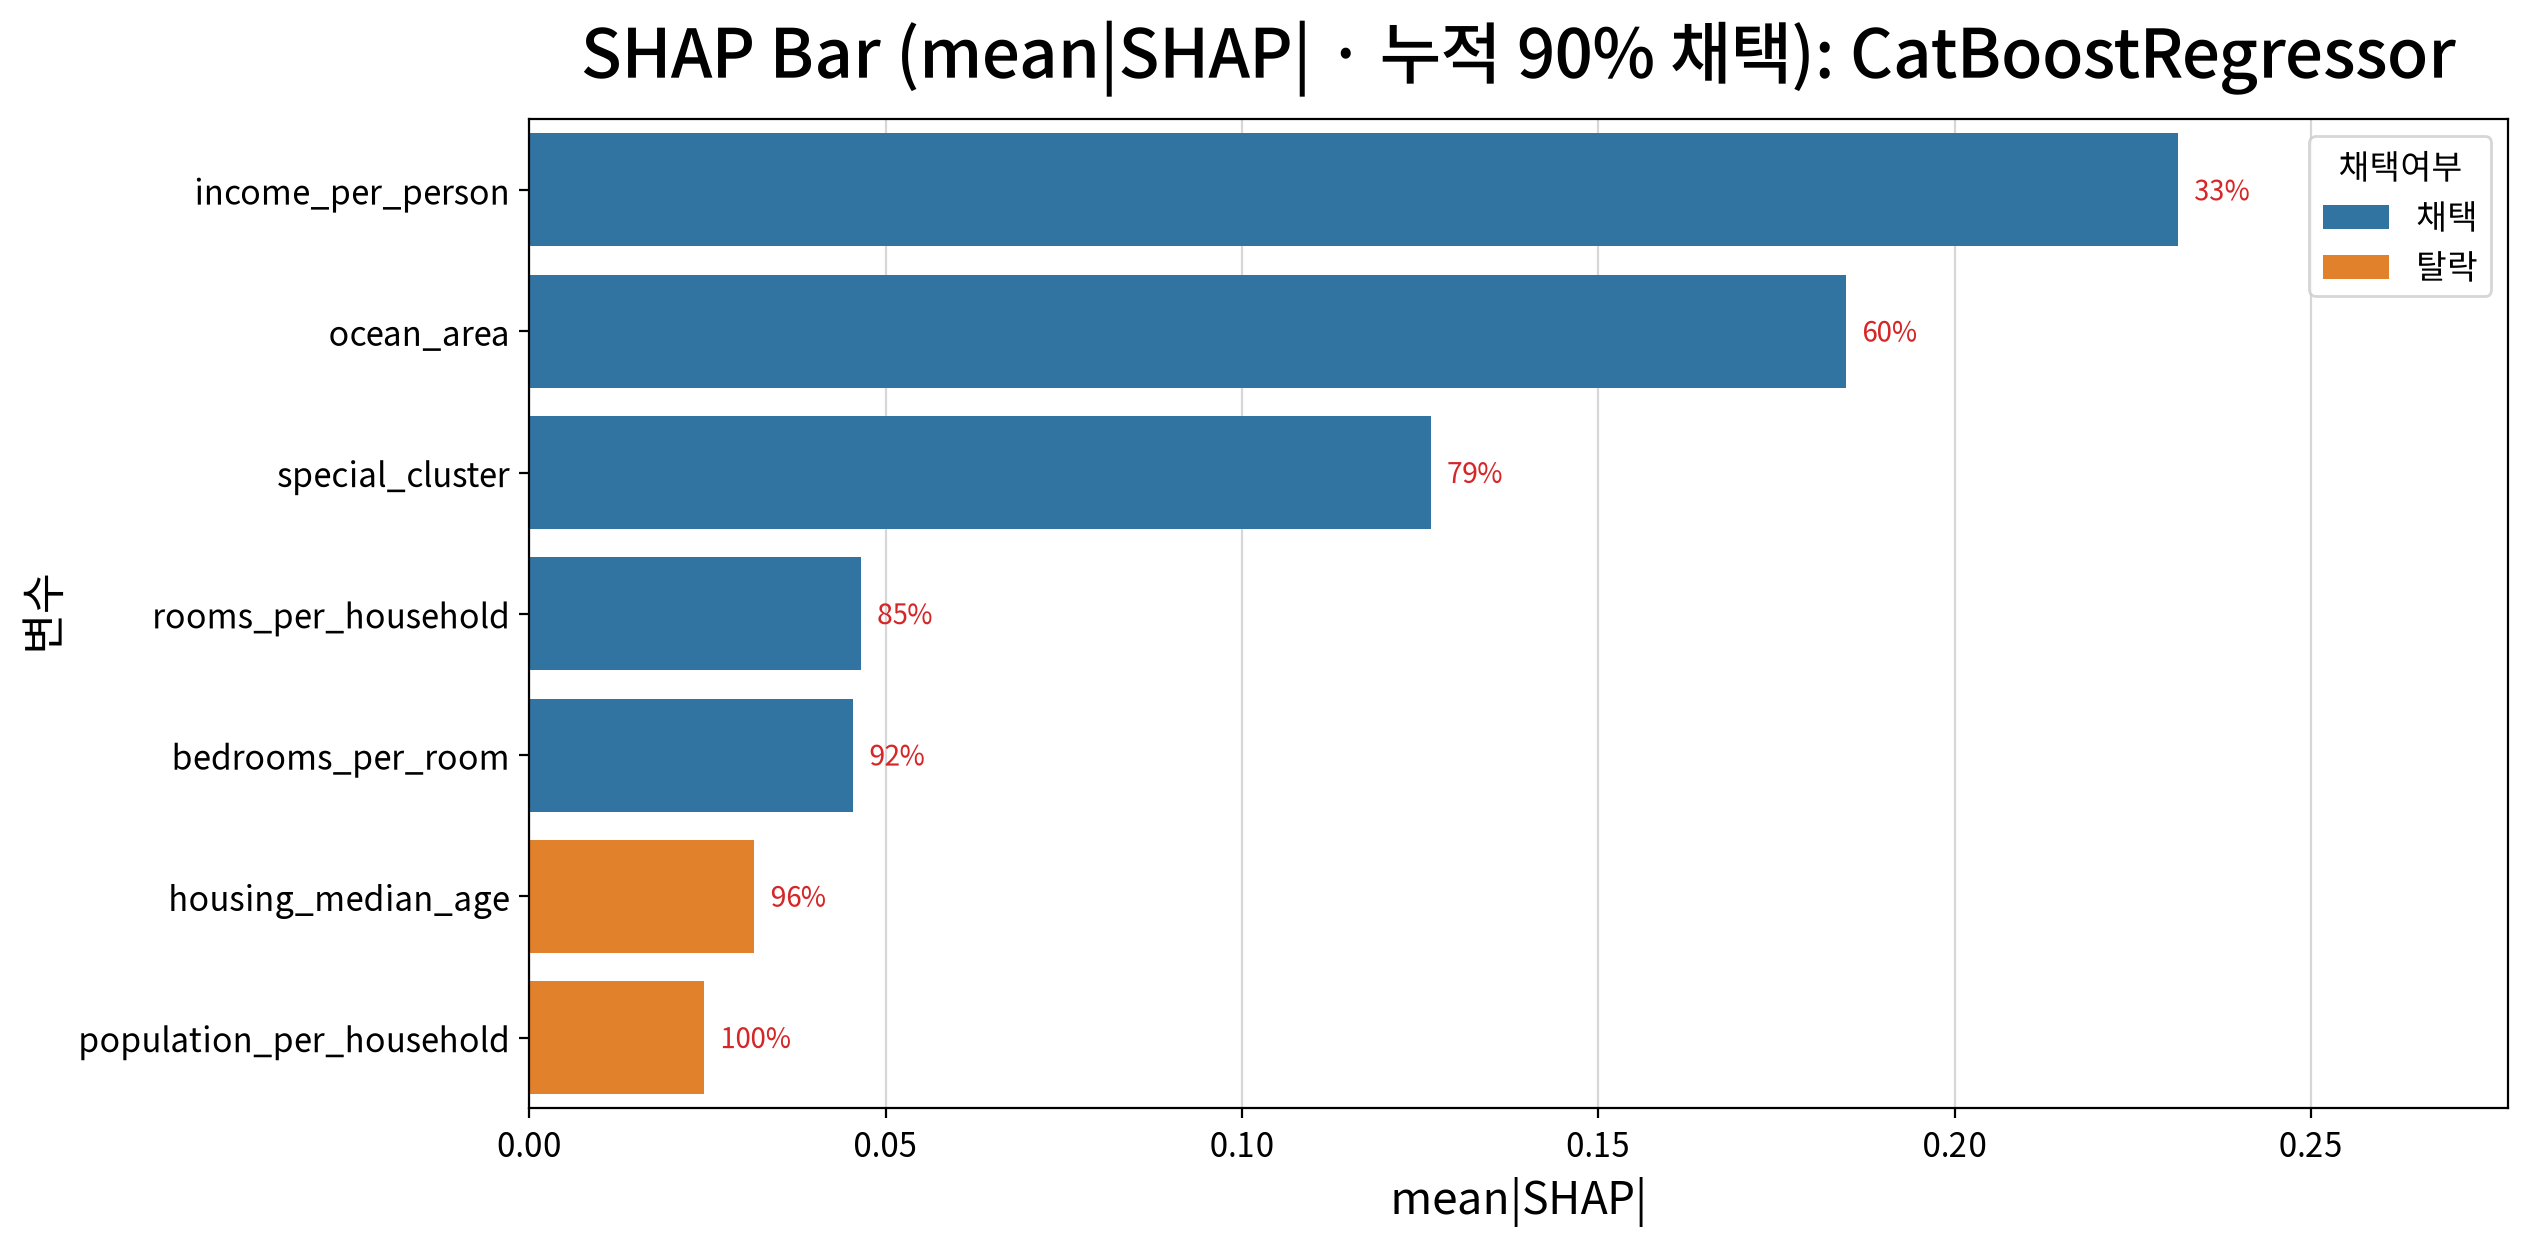

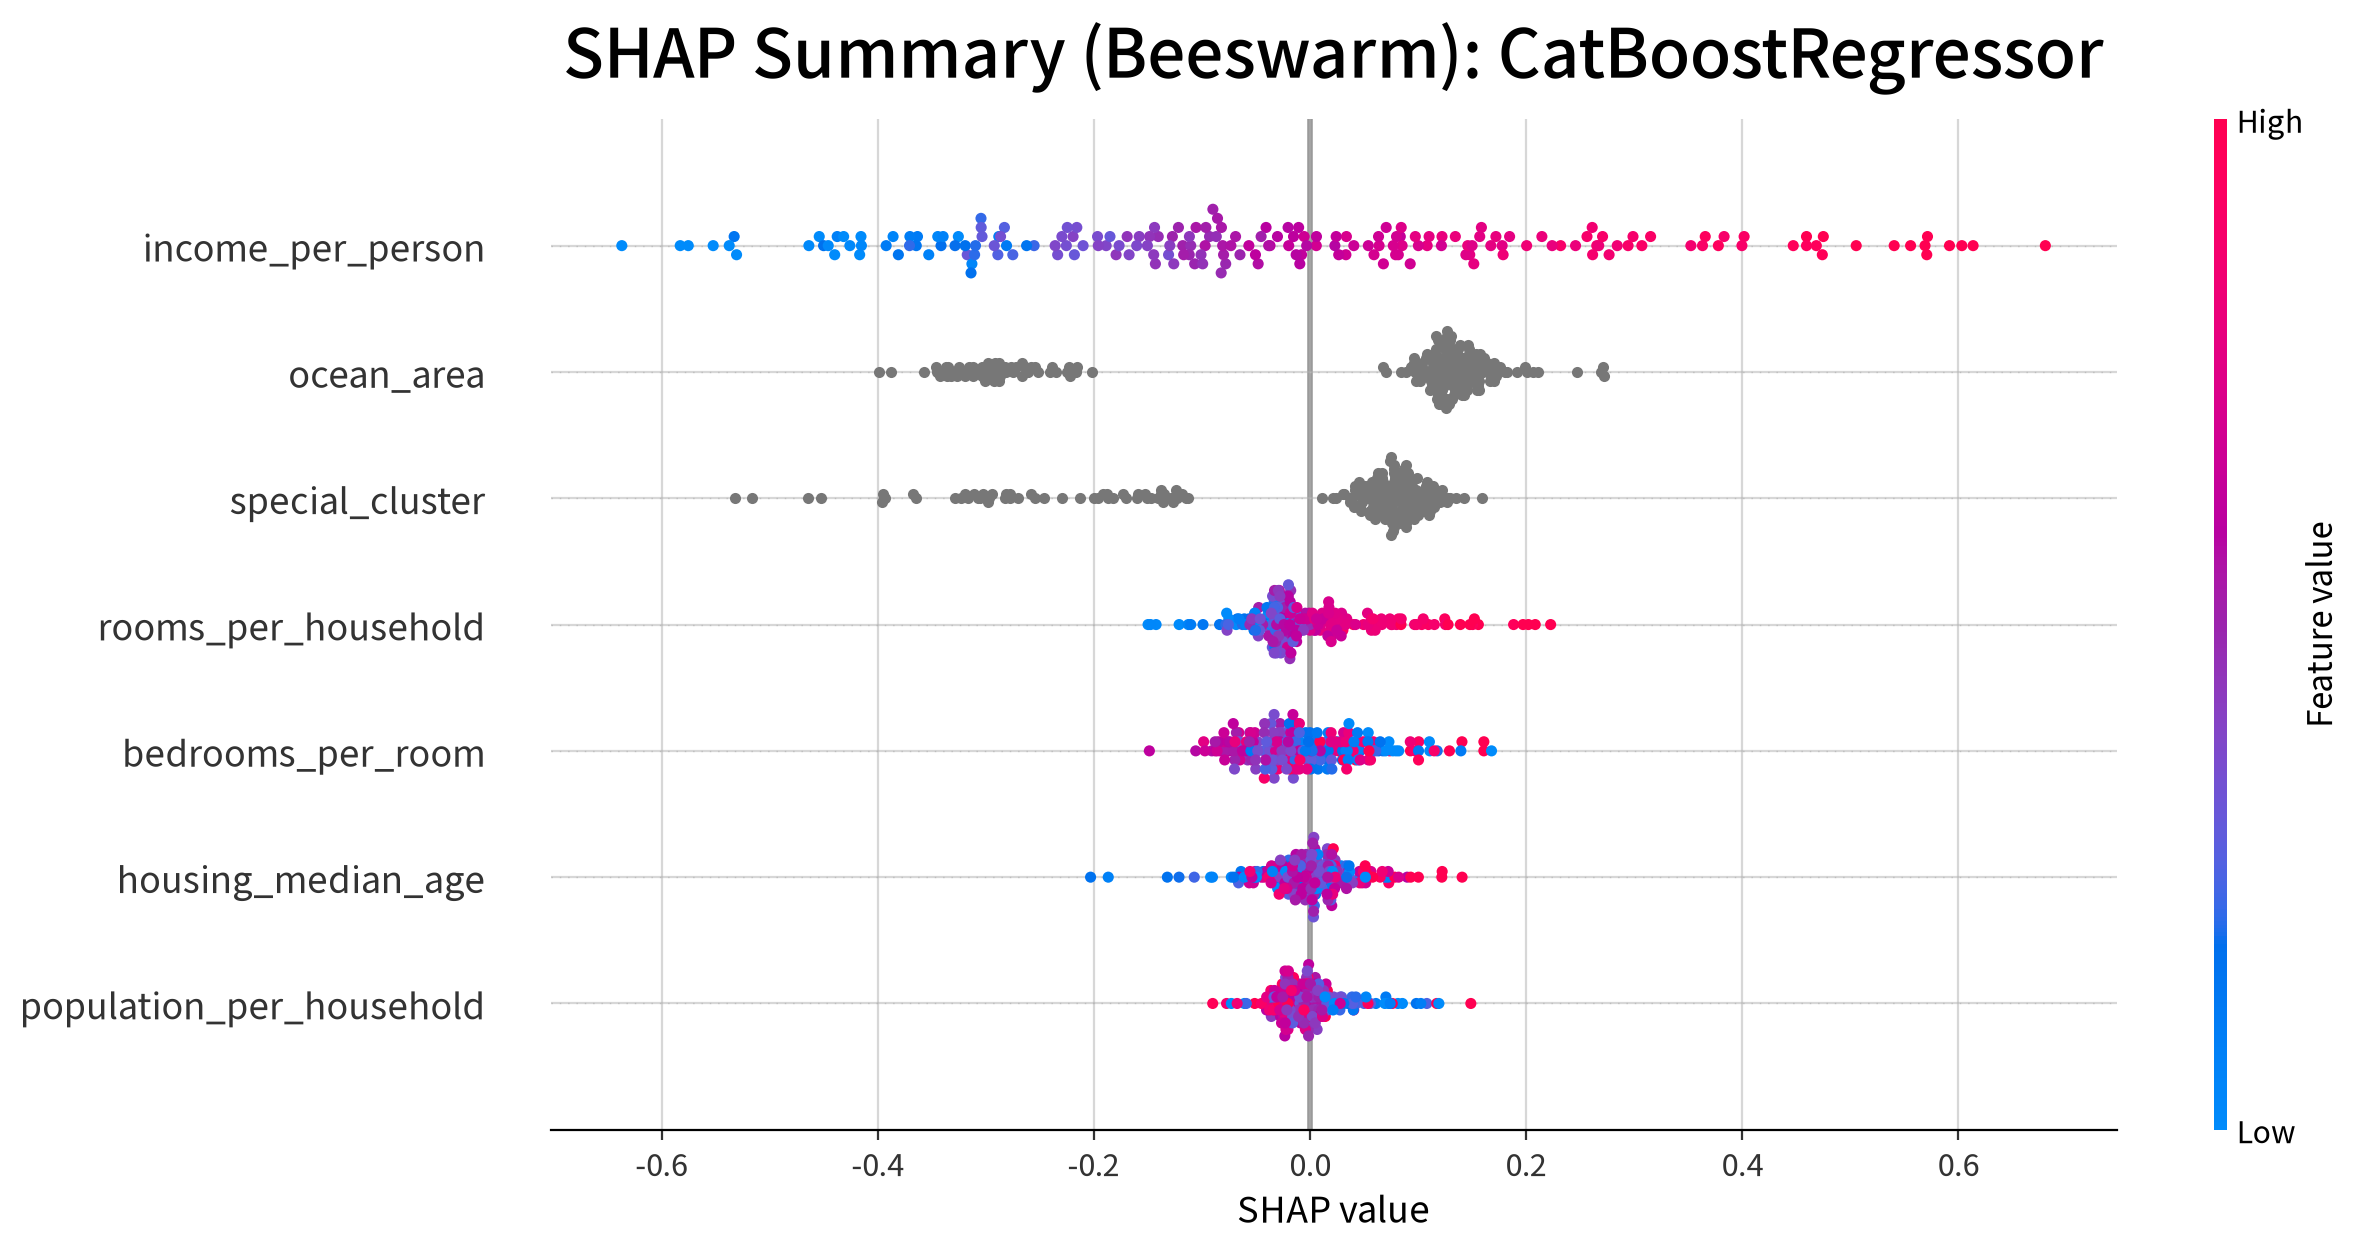


◆ SHAP Analysis: CatBoostRegressor  (TreeExplainer, regression)
   ▷ 탐색 객체의 best_params: {'model__depth': 8, 'model__iterations': 1000, 'model__learning_rate': 0.03}
   설명 표본 200행 × 변수 7개 · base value=12.0859
   income_per_person      mean|SHAP|=0.2314  방향=감소  비선형/불안정
   ocean_area             mean|SHAP|=0.1847  방향=증가  비선형/불안정
   special_cluster        mean|SHAP|=0.1265  방향=감소  비선형/불안정
   rooms_per_household    mean|SHAP|=0.0465  방향=증가  비선형/불안정
   bedrooms_per_room      mean|SHAP|=0.0455  방향=감소  비선형/불안정



In [47]:
# 앞에서 학습 완료한 최종 모델과 데이터 사용
shap = my_ml.shap_analysis(gs, x_tr)

#### 📌 인사이트 ① Bar Plot — 전역 영향력 순위

- **상위 3개가 영향력의 79%**: `income_per_person`(33%) → `ocean_area`(60%) → `special_cluster`(79%). 사실상 "소득 · 해안입지 · 공간클러스터" 세 축으로 가격이 결정된다.
- **채택 5개 / 탈락 2개**: 누적 90% 기준으로 `rooms_per_household`(85%)·`bedrooms_per_room`(92%)까지 채택되고, `housing_median_age`·`population_per_household`는 탈락했다. 주거 구조 변수 4개를 다 합쳐도 상위 1개(소득)에 미치지 못한다.
- **파생변수가 1·3위**: 원본 컬럼이 아니라 직접 만든 `income_per_person`·`special_cluster`가 상위권 → 피처 엔지니어링이 실제로 성능에 기여했다는 근거.
- **효과 크기 감각**: 종속변수가 로그 변환되어 있으므로 `income_per_person`의 mean|SHAP| 0.231은 평균적으로 exp(0.231) ≈ **약 ±26%의 가격 차이**를 만든다는 뜻이다.
- 앞 단계의 `feature_importance`(CatBoost 내부 지표)가 뽑은 변수 구성과 SHAP 순위가 일치하면 변수 선택이 견고하다는 교차 검증이 된다. 서로 다르다면 SHAP 쪽을 신뢰한다.

#### 📌 인사이트 ② Beeswarm — 방향과 분포

- **`income_per_person`은 명확한 증가 관계**: 빨강(고소득)이 오른쪽(+0.68까지), 파랑(저소득)이 왼쪽(−0.65까지)에 위치한다. 유일하게 좌우로 넓게 퍼져 개별 예측의 편차를 가장 크게 만드는 변수다.
- **⚠️ 콘솔 출력의 `방향=감소`는 함정**: 이 값은 `mean_shap`의 부호일 뿐이다. 저소득 쪽 꼬리가 더 길고 두꺼워 평균이 음수로 나왔을 뿐, 실제 관계는 그래프대로 **증가**다. 방향 해석은 Beeswarm으로 하고 요약표의 `direction`은 참고만 한다.
- **`ocean_area`·`special_cluster`가 회색인 이유는 범주형이기 때문**: 값의 크기가 없어 색이 칠해지지 않은 것이지 오류가 아니다. 두 변수 모두 SHAP 값이 **음의 덩어리와 양의 덩어리로 완전히 분리**되는 전형적인 범주 효과를 보인다.
- **효과가 비대칭이다**: 음의 그룹은 −0.2 ~ −0.45로 강하게 끌어내리는 반면, 양의 그룹은 +0.1 부근으로 완만하게 올린다. 즉 "좋은 입지의 프리미엄"보다 **"불리한 입지의 페널티"가 훨씬 크다**.
- **`bedrooms_per_room`은 색이 뒤섞여 있다**: 빨강·파랑이 좌우로 섞여 단조 관계가 아니다 → 상호작용·비선형을 의심할 지점이며, 요약표의 `비선형/불안정` 판정과 일치한다. Dependence Plot에서 가장 먼저 확인할 변수다.
- **하위 2개는 0 근처에 밀집**: `housing_median_age`·`population_per_household`는 대부분의 예측에서 기여가 없고 일부 극단 케이스에만 ±0.15 정도 반응한다 → 제거해도 예측이 거의 바뀌지 않을 변수다.

#### 📌 종합

- 모델은 **소득 + 입지(해안·클러스터)** 로 가격의 8할을 설명하고, 주거 구조 변수는 미세 조정 역할에 그친다.

### 2. Dependence Plot

◆ SHAP Dependence — 변수쌍(주변수 × 상호작용변수) · 선정기준=cum_ratio=90%
   income_per_person  ×  bedrooms_per_room
   ocean_area  ×  special_cluster
   special_cluster  ×  rooms_per_household
   rooms_per_household  ×  income_per_person
   bedrooms_per_room  ×  rooms_per_household


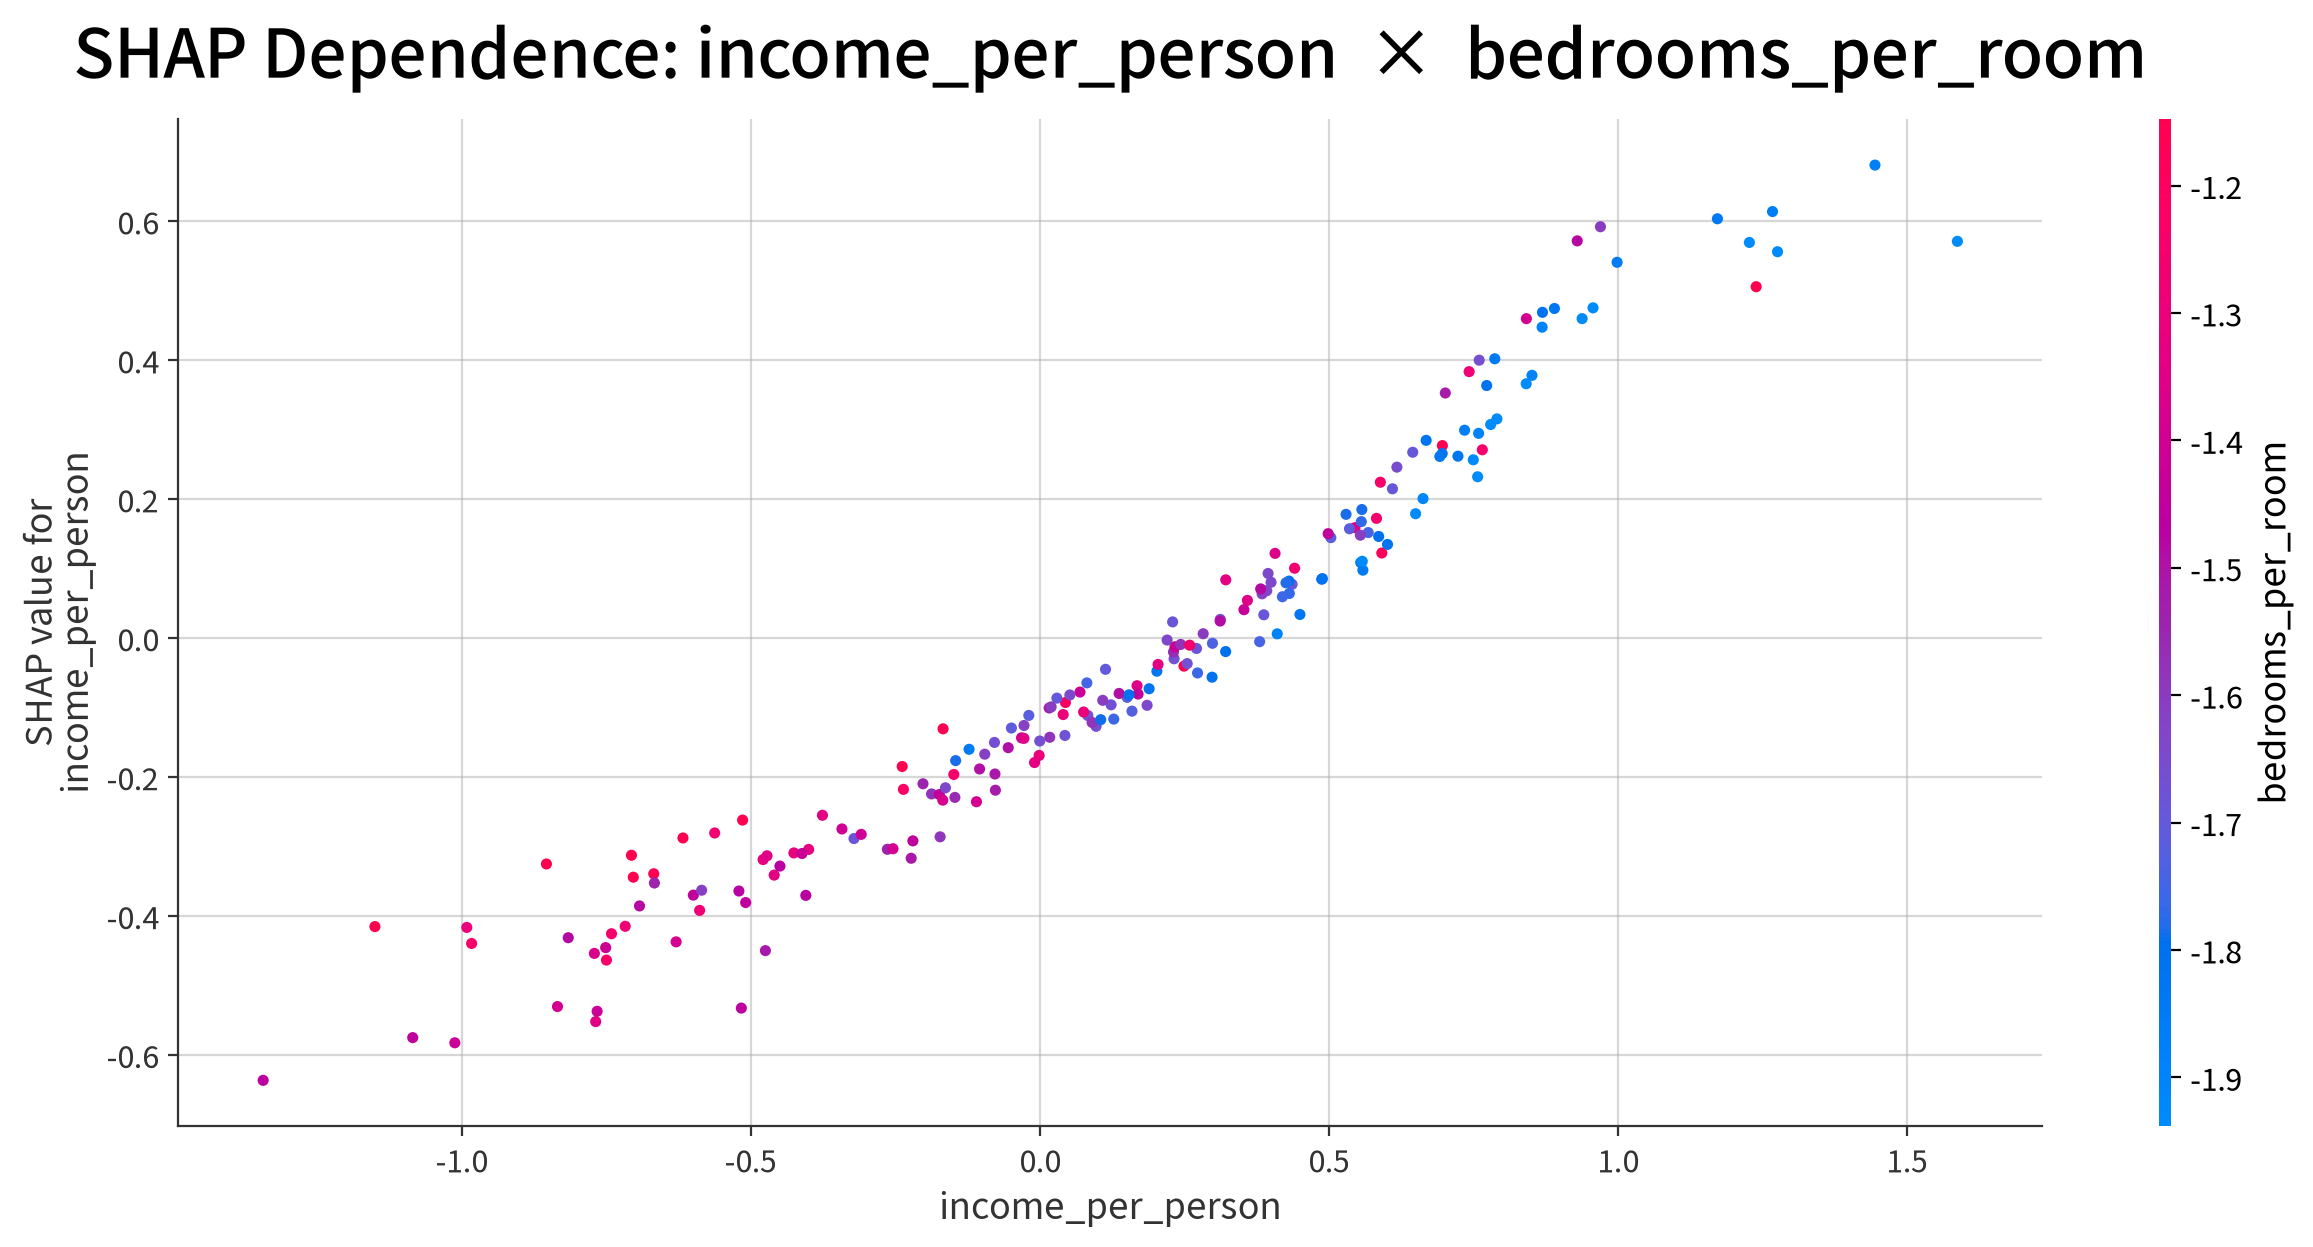

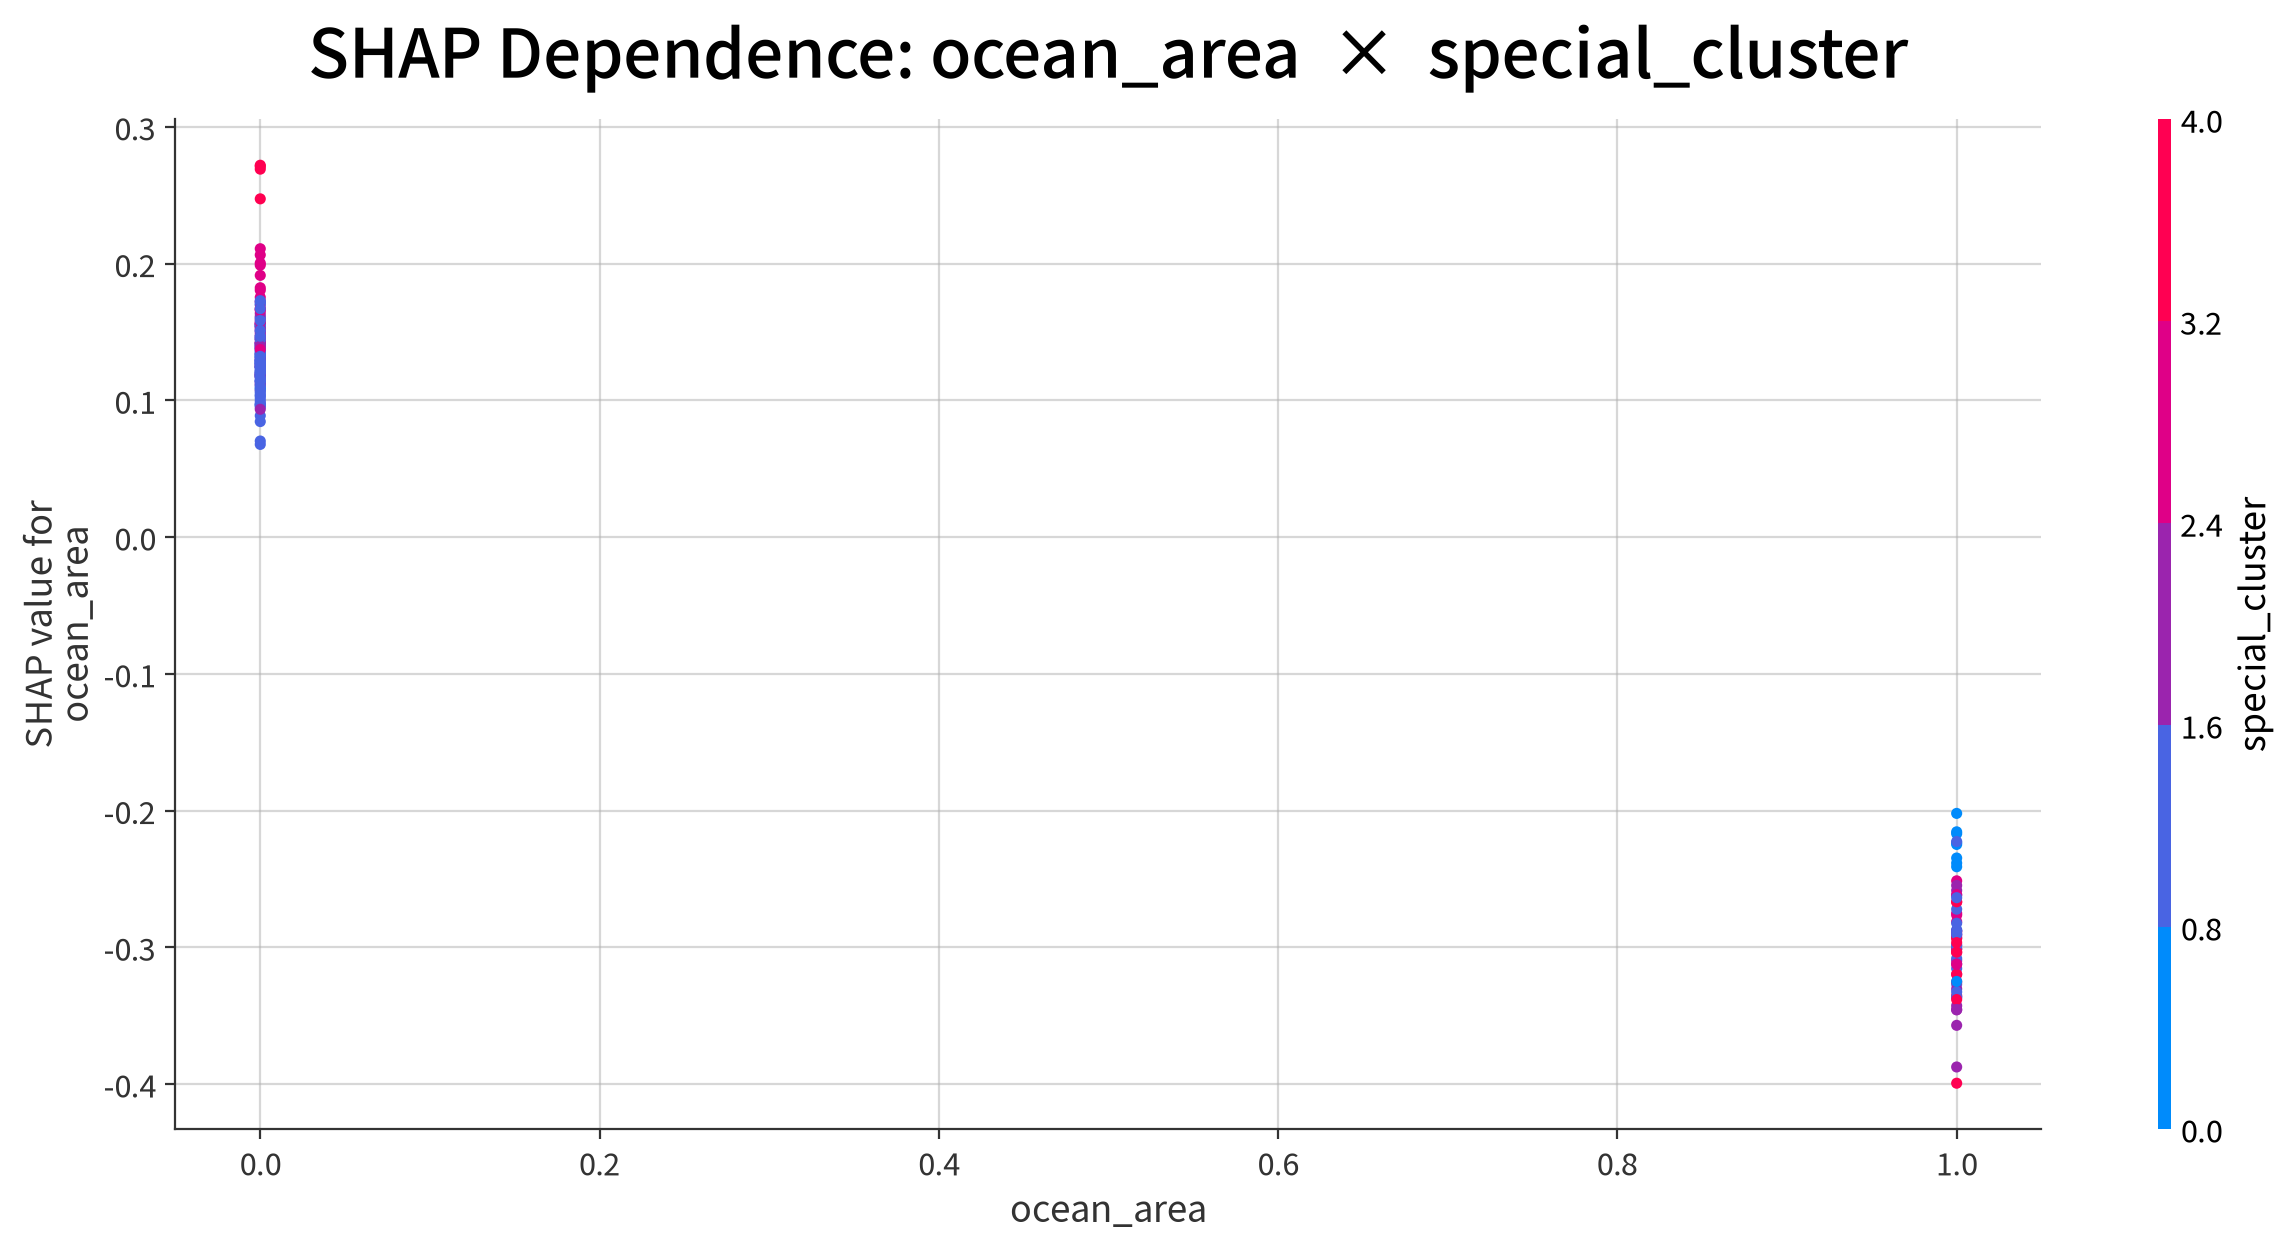

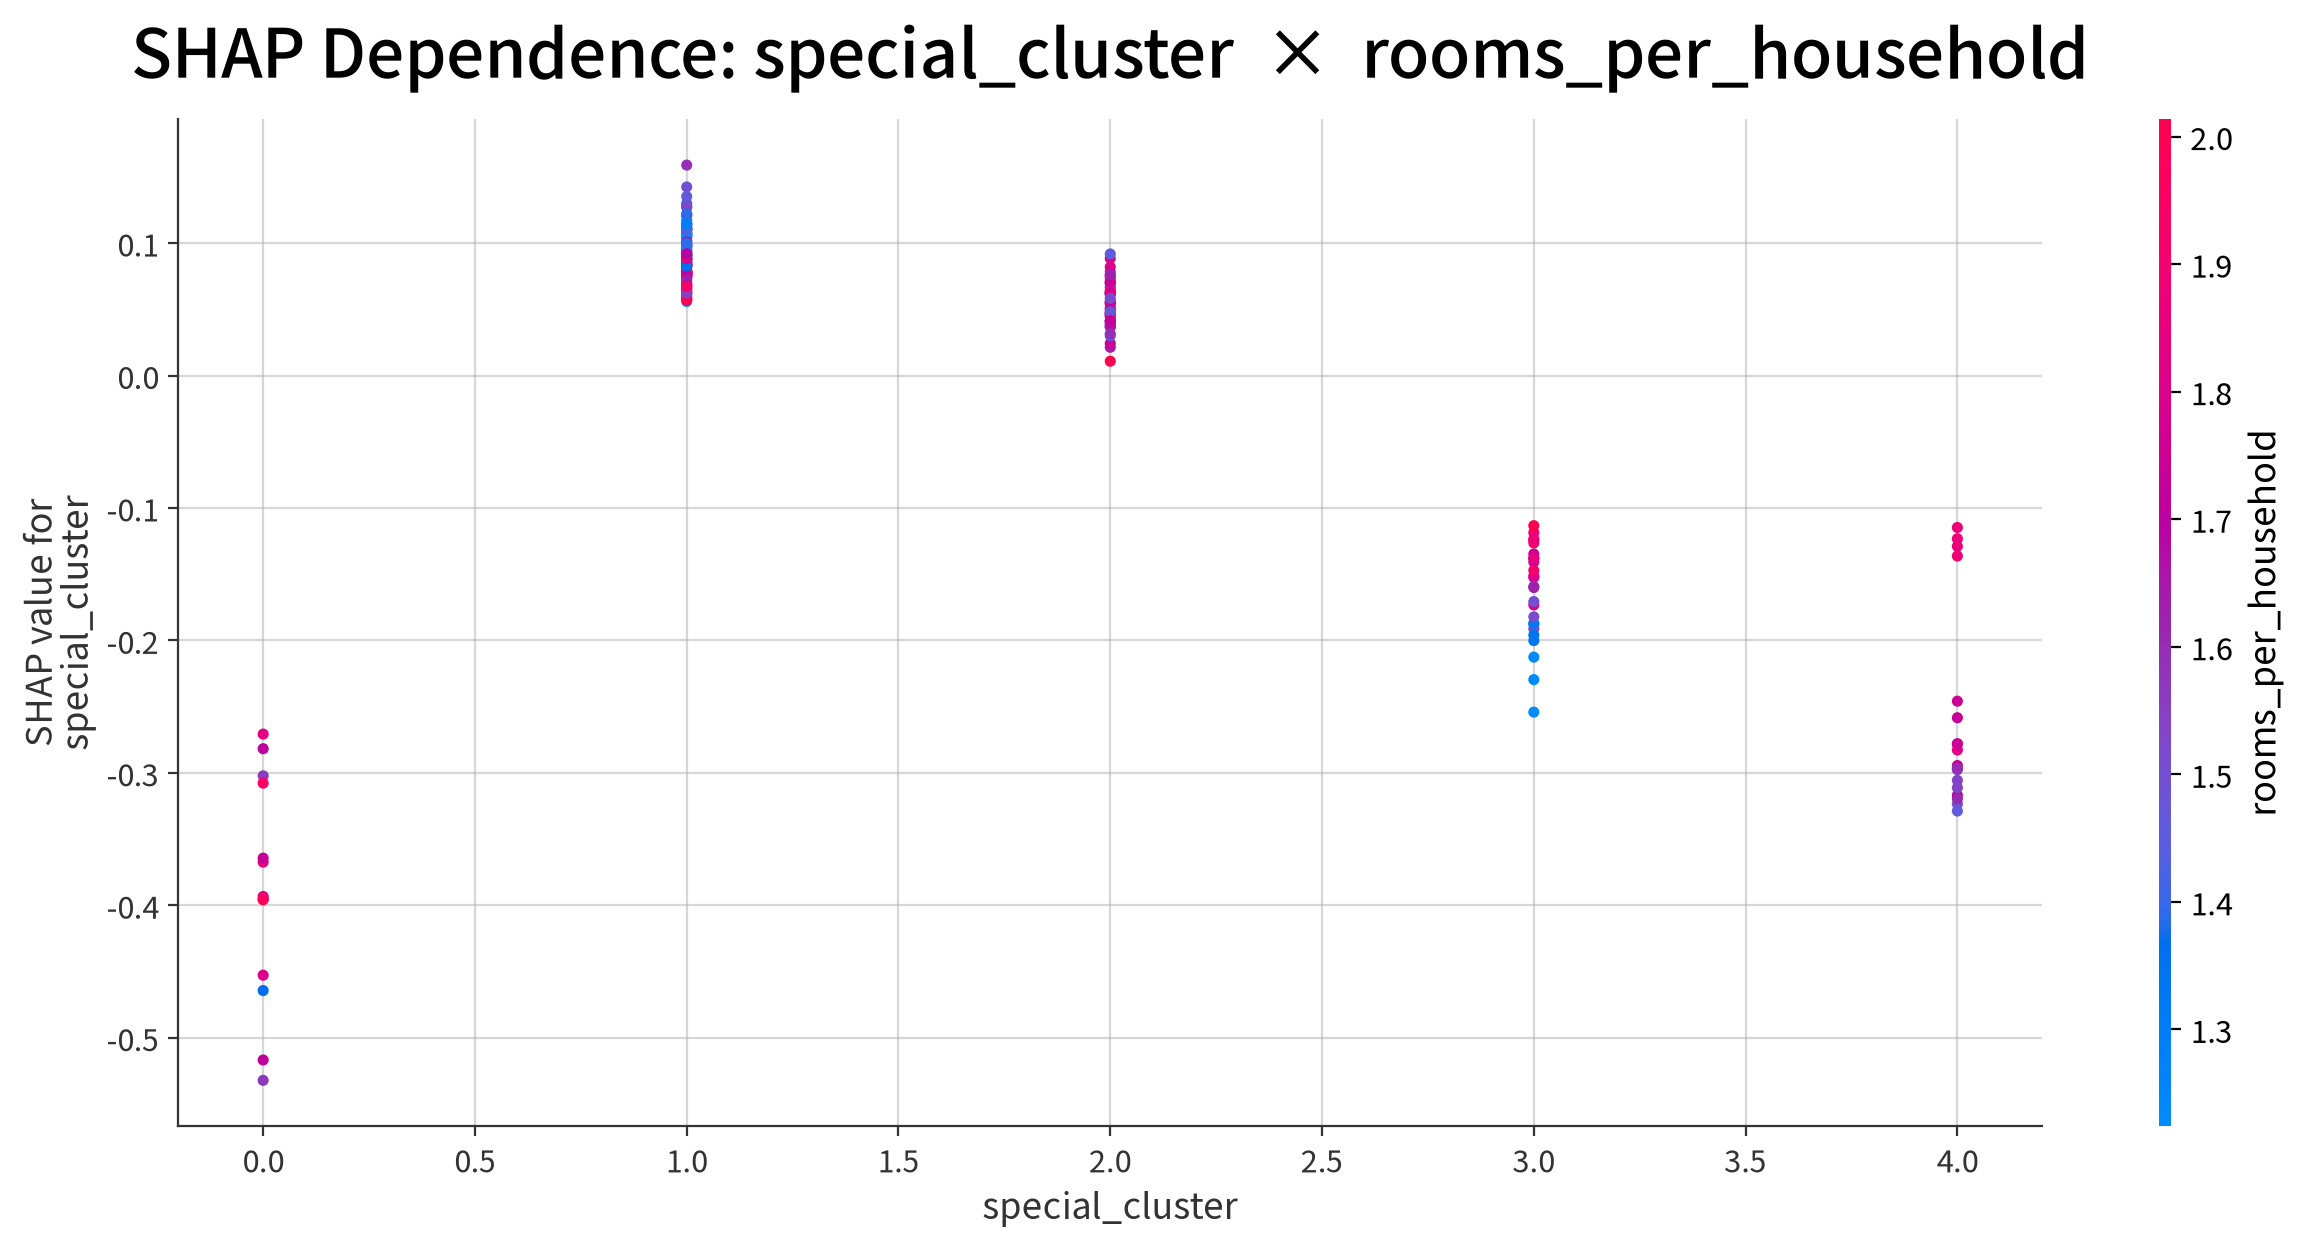

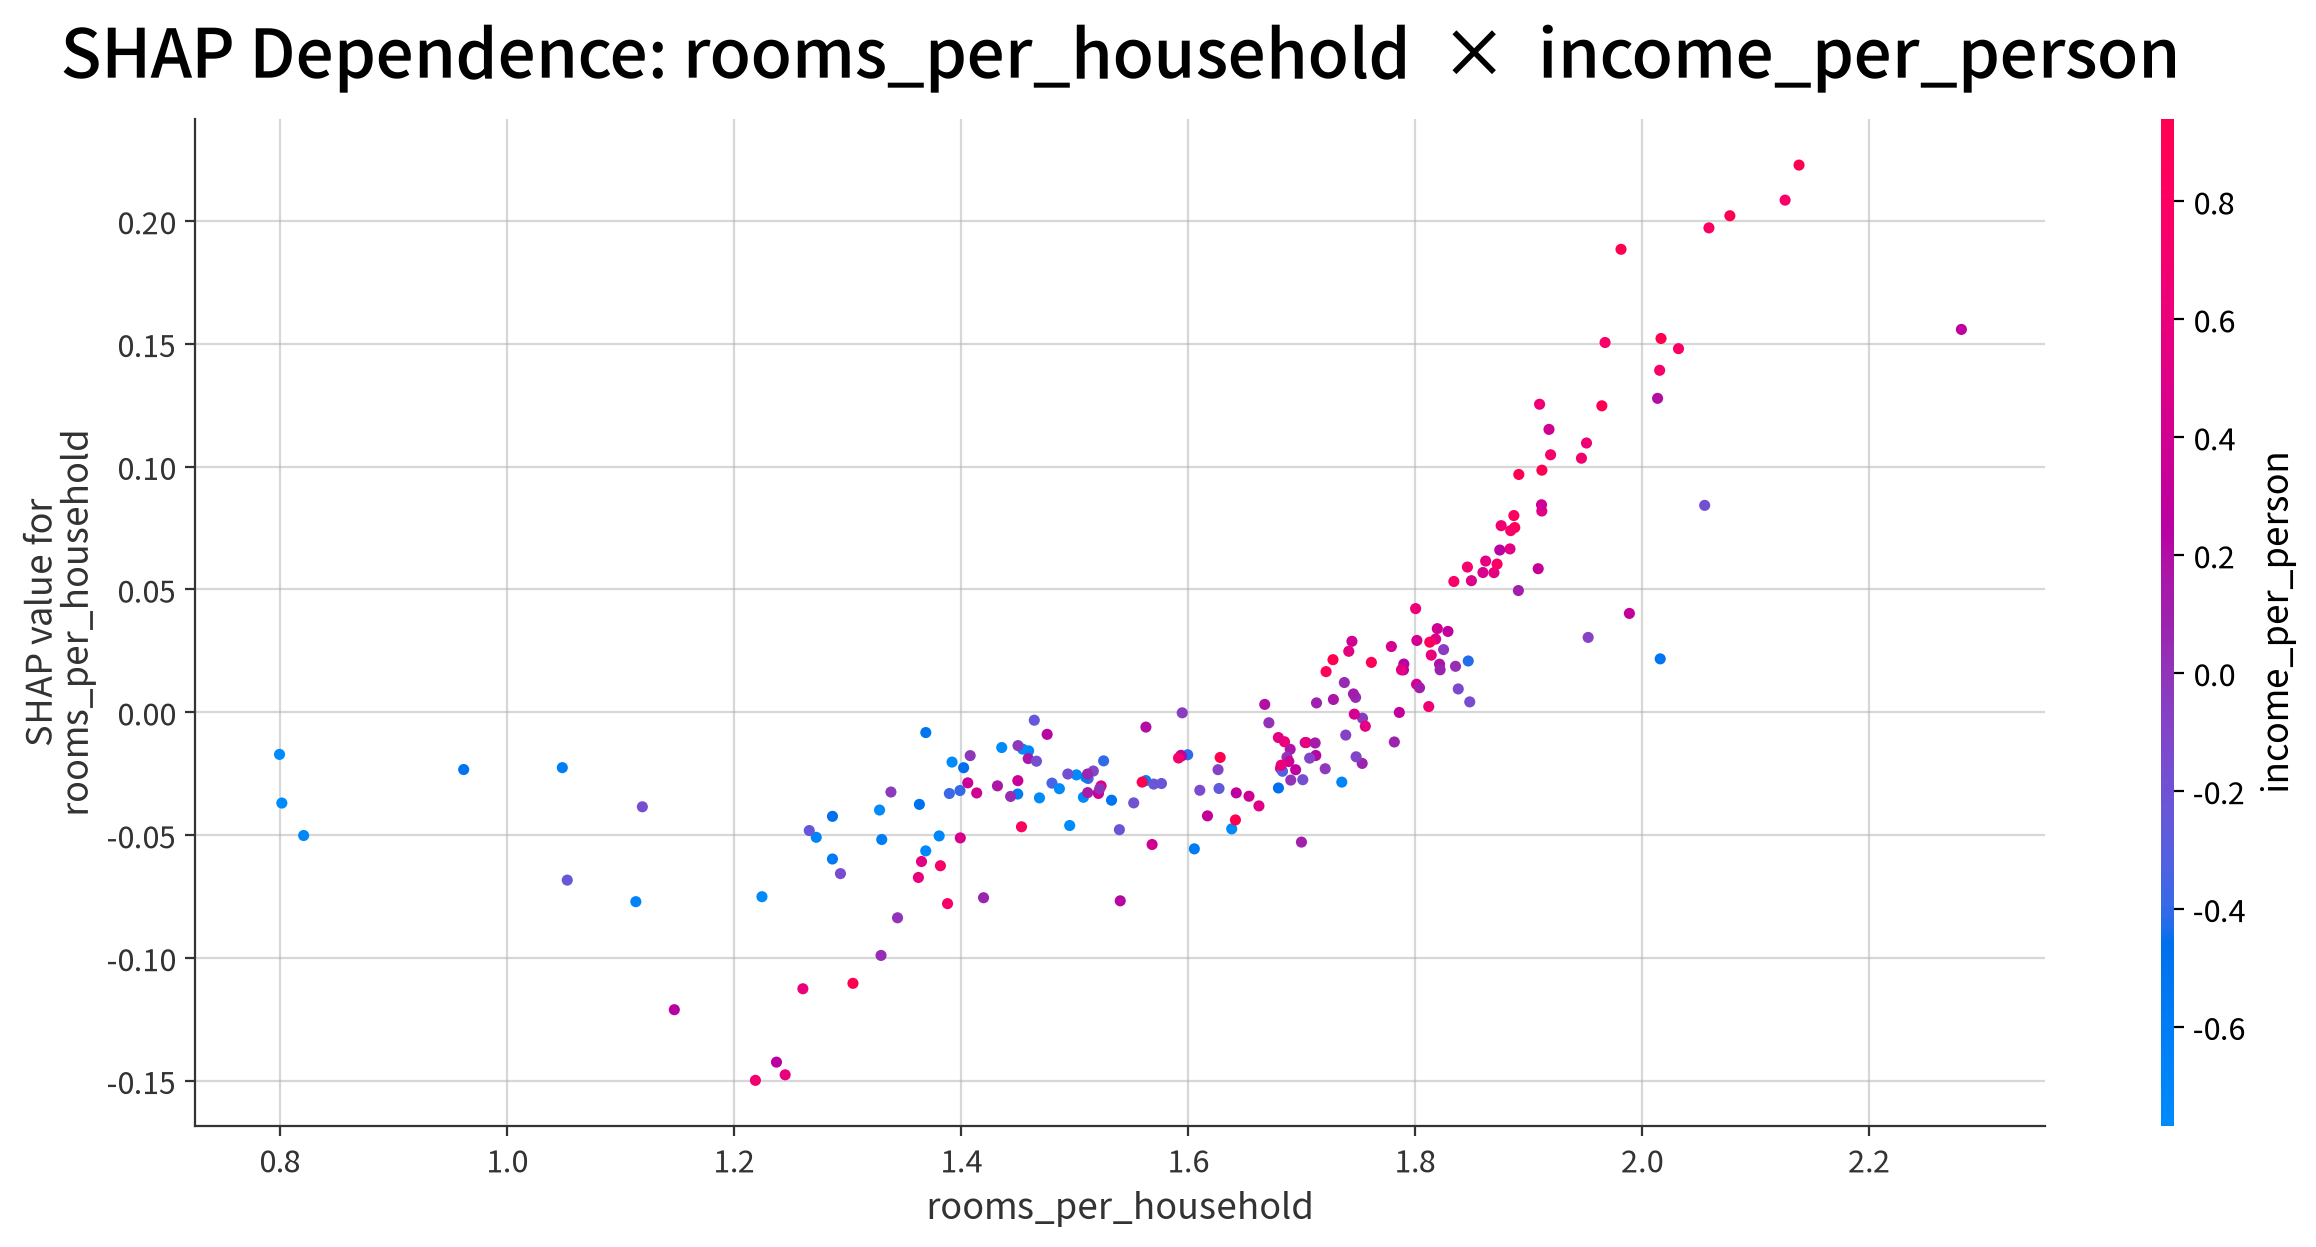

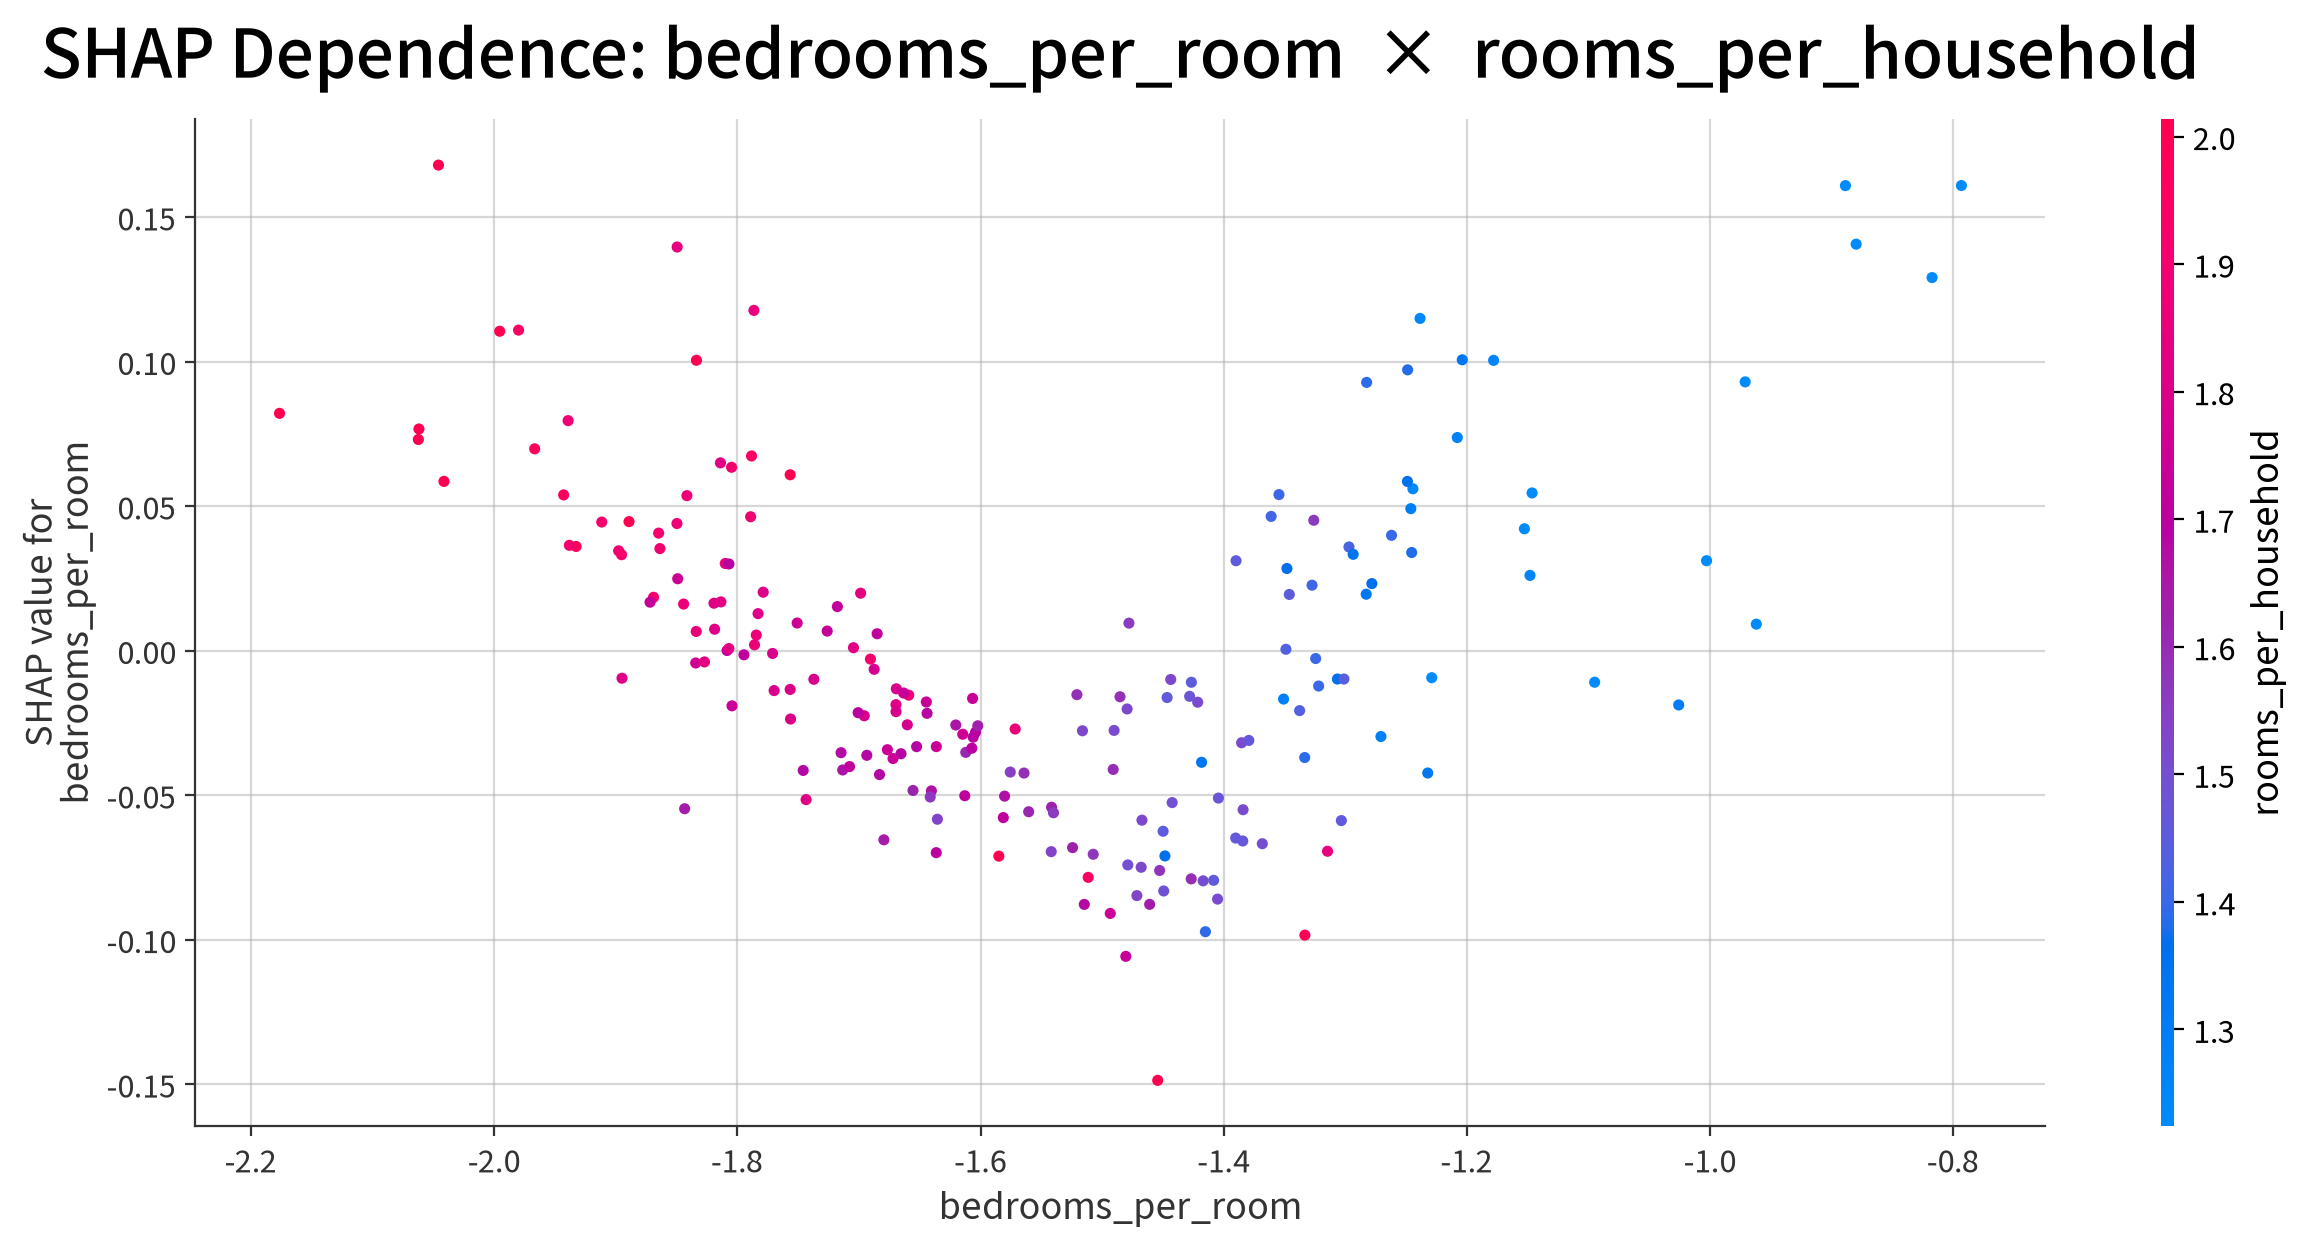

[{'feature': 'income_per_person', 'interaction_feature': 'bedrooms_per_room'},
 {'feature': 'ocean_area', 'interaction_feature': 'special_cluster'},
 {'feature': 'special_cluster', 'interaction_feature': 'rooms_per_household'},
 {'feature': 'rooms_per_household',
  'interaction_feature': 'income_per_person'},
 {'feature': 'bedrooms_per_room',
  'interaction_feature': 'rooms_per_household'}]

In [48]:
# 데이터는 shap.attrs 에서 읽으므로 훈련데이터를 넘기지 않는다.
# features 를 비워야 cum_ratio/top_k 자동선정이 동작한다.
my_ml.shap_dependence_plot(shap)

#### 📌 인사이트 ① `income_per_person` × `bedrooms_per_room`

- **거의 직선에 가까운 단조 증가**: SHAP이 −0.65 ~ +0.68로 가장 넓게 움직이며, 소득 로그값 0 부근에서 SHAP이 0을 교차한다. 즉 **평균 소득이 가격 기준선**이고 그보다 높으면 가산, 낮으면 감산이다.
- **점들이 좁은 띠 하나로 모여 있다**: 같은 소득이면 다른 변수와 무관하게 기여가 거의 같다 → 상호작용이 거의 없는 **순수 주효과**. 모델이 소득을 단순·안정적으로 학습했다는 뜻이라 신뢰도가 높다.
- **색은 상호작용이 아니라 상관을 보여준다**: 왼쪽(저소득)은 빨강, 오른쪽(고소득)은 파랑으로 **가로 방향**으로 갈린다. 세로 방향(같은 x에서 색 분리)이 아니므로 상호작용이 아니라 두 변수의 강한 음의 상관(소득이 낮을수록 침실 비율이 높음)이 찍힌 것이다.
- **양 끝에서 기울기가 완만해진다**: 소득 −1.0 이하, +1.0 이상 구간에서 곡선이 눕는다 → 극단 소득대에서는 추가 소득의 가격 효과가 체감된다.

#### 📌 인사이트 ② `ocean_area` × `special_cluster`

- **두 그룹이 완전히 분리된다**: 0 그룹은 +0.07 ~ +0.27, 1 그룹은 −0.20 ~ −0.40으로 겹치는 구간이 전혀 없다. 이 변수 하나로 예측이 뚜렷하게 갈린다.
- **페널티가 프리미엄보다 2배 크다**: 1(내륙) 그룹의 평균 −0.3은 약 **−26%**, 0(해안) 그룹의 +0.14는 약 **+15%**에 해당한다(로그 스케일 환산). 모델은 "해안이라 좋다"보다 **"내륙이라 나쁘다"를 훨씬 강하게 학습**했다.
- **그룹 안의 세로 산포(±0.1)는 색으로 설명되지 않는다**: `special_cluster` 색(빨강·파랑)이 위아래로 섞여 있다 → 두 입지 변수 사이의 상호작용은 뚜렷하지 않고, 산포는 다른 변수(소득 등)에서 온다.

#### 📌 인사이트 ③ `special_cluster` × `rooms_per_household`

- **클러스터별 기여가 계단식으로 뚜렷하다**: 1(+0.10) ≈ 2(+0.05) → 3(−0.17) → 4(−0.28) → 0(−0.40). 즉 **1·2는 가격을 올리는 지역, 0·3·4는 내리는 지역**으로 이분된다.
- **클러스터 0이 가장 강한 하락 요인**: −0.27 ~ −0.53(약 −24% ~ −41%)까지 내려가며, 다른 클러스터보다 산포도 크다. 다만 표본에 찍힌 점이 10여 개로 적어 **수치를 단정하기 전에 원 데이터의 해당 클러스터 규모를 확인**해야 한다.
- **약한 상호작용의 흔적**: 클러스터 3에서만 파랑(방 수 적음)이 아래쪽에 몰려 있다 → 클러스터 3 안에서는 방 수가 적을수록 추가 페널티를 받는다. 나머지 클러스터에서는 색이 고르게 섞여 있어 상호작용이 없다.

#### 📌 인사이트 ④ `rooms_per_household` × `income_per_person`

- **임계효과(hockey stick) 패턴**: 1.2 ~ 1.8 구간은 −0.05 부근에서 거의 평평하다가, **1.8을 넘어가면 급격히 상승**해 +0.22까지 간다. 방 수는 일정 수준을 넘어야 비로소 가격을 올린다.
- **이 그래프에만 진짜 상호작용이 보인다**: 상승 구간이 대부분 빨강(고소득)이고, 같은 방 수(≈2.0)라도 파랑(저소득)이면 SHAP이 +0.02 ~ +0.08에 그친다. **세로 방향으로 색이 갈리므로 "방 많음 × 소득 높음" 조합에서만 프리미엄이 발생**하는 상호작용이다.
- **왼쪽 끝은 해석하지 말 것**: 0.8 ~ 1.2 구간은 점이 6개 남짓이라 추세를 논할 근거가 없다.

#### 📌 인사이트 ⑤ `bedrooms_per_room` × `rooms_per_household`

- **뚜렷한 U자(비단조)**: 양 끝(−2.2 이하, −1.0 이상)에서 SHAP이 +0.1 이상으로 올라가고, 중앙(−1.6 ~ −1.45)에서 −0.05 ~ −0.10으로 최저가 된다. **침실 비율이 "중간"인 주택이 오히려 가격에 마이너스**다.
- **요약표의 `비선형/불안정` 판정의 실체가 이것**이며, 선형회귀로는 절대 잡을 수 없는 패턴이다. **트리 계열(CatBoost)을 쓴 것이 정당하다는 직접적 근거**로 쓸 수 있다.
- **U자의 양 끝은 서로 다른 주택 유형이다**: 색이 좌우로 완전히 갈린다(왼쪽 빨강=방 많음, 오른쪽 파랑=방 적음). 왼쪽 극단은 **방이 많고 침실 비율이 낮은 대형 주택**, 오른쪽 극단은 **방이 적고 침실 비율이 높은 소형·임대형 주택**으로, 두 유형 모두 중간 유형보다 가격을 끌어올린다.

#### 📌 종합

- 자동 선정 기준은 누적 mean|SHAP| 90%로, 상위 5개 변수(`income_per_person`·`ocean_area`·`special_cluster`·`rooms_per_household`·`bedrooms_per_room`)가 주변수로 잡혔다.
- **①②③은 사실상 주효과**이고, **진짜 상호작용은 ④(방 수 × 소득) 하나**다. 판별 기준은 간단하다 — 색이 **가로**로 갈리면 변수 간 상관, **세로**로 갈리면 상호작용이다.
- **비선형 발견 2건**: ④의 임계효과와 ⑤의 U자. 보고서에 "왜 선형 모델이 아니라 부스팅을 썼는가"를 쓸 때 이 두 그래프가 근거가 된다.